## Puesta a punto: dependencias, fuente C y compilación

La siguiente celda escribe el fuente C (validado) a disco y lo compila con `-O3
-march=native`. Si no tienes `gcc`, instálalo (`sudo apt install gcc`).

In [3]:
import os, sys, subprocess, hashlib, json
from io import StringIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from concurrent.futures import ThreadPoolExecutor, as_completed

plt.rcParams.update({"figure.dpi":110, "font.size":11, "axes.grid":True,
                     "grid.alpha":0.3, "figure.figsize":(7,4.5)})
print("Python", sys.version.split()[0], "| numpy", np.__version__, "| pandas", pd.__version__)

Python 3.11.14 | numpy 2.1.3 | pandas 2.3.3


In [2]:
C_SOURCE = r"""/* ============================================================================
 *  sis_lifespan.c
 *
 *  Dinamica SIS sobre redes del configuration model con grado power-law,
 *  simulada con el algoritmo de Gillespie y analizada con el "lifespan method"
 *  (Mata, Boguna, Castellano, Pastor-Satorras, Phys. Rev. E 91, 052117 (2015)).
 *
 *  - delta (tasa de recuperacion) = 1  ->  el control es lambda = lambda/delta.
 *  - Parametro de orden:       Pend(lambda,N)  = P(realizacion endemica).
 *  - Susceptibilidad:          <tau(lambda,N)> = vida media de las NO endemicas.
 *  - Endemica := la cobertura (nodos distintos infectados) alcanza cth*N.
 *
 *  Estructuras de datos clave (todas con insercion/borrado O(1)):
 *    inf_list[]  : nodos infectados (los primeros n_inf).
 *    act[]       : aristas activas, identificadas por su id de arista DIRIGIDA
 *                  (infectado -> susceptible). act_pos[] guarda la posicion de
 *                  cada arista dirigida dentro de act[] para poder borrar en O(1)
 *                  (esto es el "additional data structure" del enunciado).
 *    rev[]       : para cada arista dirigida, el id de su arista inversa.
 *
 *  Compilar:  gcc -O3 -march=native -o sis_lifespan sis_lifespan.c -lm
 * ==========================================================================*/

#include <stdio.h>
#include <stdlib.h>
#include <string.h>
#include <math.h>
#include <stdint.h>
#include <time.h>

/* ----------------------------- RNG: xoshiro256** --------------------------- */
static uint64_t RNG[4];

static inline uint64_t splitmix64(uint64_t *x) {
    uint64_t z = (*x += 0x9E3779B97F4A7C15ULL);
    z = (z ^ (z >> 30)) * 0xBF58476D1CE4E5B9ULL;
    z = (z ^ (z >> 27)) * 0x94D049BB133111EBULL;
    return z ^ (z >> 31);
}
static void rng_seed(uint64_t seed) {
    uint64_t s = seed ? seed : 0x123456789ABCDEFULL;
    for (int i = 0; i < 4; i++) RNG[i] = splitmix64(&s);
}
static inline uint64_t rotl(const uint64_t x, int k) { return (x << k) | (x >> (64 - k)); }
static inline uint64_t rng_next(void) {
    const uint64_t result = rotl(RNG[1] * 5, 7) * 9;
    const uint64_t t = RNG[1] << 17;
    RNG[2] ^= RNG[0]; RNG[3] ^= RNG[1]; RNG[1] ^= RNG[2]; RNG[0] ^= RNG[3];
    RNG[2] ^= t; RNG[3] = rotl(RNG[3], 45);
    return result;
}
/* doble en [0,1) */
static inline double rng_unit(void) {
    return (double)(rng_next() >> 11) * (1.0 / 9007199254740992.0);
}
/* Multiplicacion 64x64 -> mitad alta, portable (sin __uint128_t).
 * Funciona en MSVC, MinGW y GCC/Linux. */
static inline uint64_t mul_hi64(uint64_t x, uint64_t y) {
    uint64_t xlo = (uint32_t)x, xhi = x >> 32;
    uint64_t ylo = (uint32_t)y, yhi = y >> 32;
    uint64_t ll = xlo * ylo;
    uint64_t lh = xlo * yhi;
    uint64_t hl = xhi * ylo;
    uint64_t hh = xhi * yhi;
    uint64_t mid = (ll >> 32) + (uint32_t)lh + (uint32_t)hl;
    return hh + (lh >> 32) + (hl >> 32) + (mid >> 32);
}

/* entero uniforme sin sesgo en [0,n)  (metodo de Lemire, portable) */
static inline uint64_t rng_below(uint64_t n) {
    uint64_t x  = rng_next();
    uint64_t lo = x * n;          /* mitad baja (desbordamiento intencionado) */
    uint64_t hi = mul_hi64(x, n);
    if (lo < n) {
        uint64_t t = (-n) % n;
        while (lo < t) { x = rng_next(); lo = x * n; hi = mul_hi64(x, n); }
    }
    return hi;
}

/* ----------------------------- Estado global ------------------------------- */
static int      N;            /* numero de nodos                               */
static long     n_edges;      /* aristas no dirigidas                          */
static long     n_dir;        /* aristas dirigidas = 2*n_edges                 */

static long    *adj_start;    /* CSR: offsets, tam N+1                         */
static int     *adj;          /* CSR: vecinos, tam n_dir                       */
static long    *rev;          /* id de la arista dirigida inversa, tam n_dir   */

static uint8_t *state;        /* 0=S, 1=I, tam N                               */
static int     *inf_list;     /* nodos infectados, tam N                       */
static long     n_inf;

static long    *act;          /* aristas activas (id dirigido), tam n_edges    */
static long    *act_pos;      /* posicion en act[] de cada arista dirigida     */
static long     n_act;

static uint8_t *covered;      /* nodo ya infectado alguna vez en la realizacion*/
static int     *touched;      /* lista de nodos cubiertos (para resetear O(cov))*/
static long     n_touch;
static long     cov;          /* cobertura actual                              */

static int     *seed_nodes;   /* nodos candidatos a semilla (grado == kmin)    */
static long     n_seed;

/* --------------------- helpers de listas dinamicas O(1) -------------------- */
static inline void add_active(long de) {
    act[n_act] = de; act_pos[de] = n_act; n_act++;
}
static inline void remove_active(long de) {
    long p = act_pos[de];
    long last = act[--n_act];
    act[p] = last; act_pos[last] = p; act_pos[de] = -1;
}
static inline void add_inf(int v) {
    inf_list[n_inf++] = v; state[v] = 1;
}

/* ---- actualizacion de aristas activas cuando un nodo cambia de estado ----- */
/* v acaba de INFECTARSE (S->I). state[v] ya = 1. */
static inline void update_SI(int v) {
    long a0 = adj_start[v], a1 = adj_start[v + 1];
    for (long de = a0; de < a1; de++) {
        int x = adj[de];
        if (state[x] == 0) add_active(de);        /* v->x pasa a activa        */
        else               remove_active(rev[de]);/* x->v estaba activa: fuera */
    }
}
/* v acaba de RECUPERARSE (I->S). state[v] ya = 0. */
static inline void update_IS(int v) {
    long a0 = adj_start[v], a1 = adj_start[v + 1];
    for (long de = a0; de < a1; de++) {
        int x = adj[de];
        if (state[x] == 0) remove_active(de);      /* v->x estaba activa: fuera */
        else               add_active(rev[de]);    /* x->v pasa a activa        */
    }
}

static int cmp_u64(const void *p, const void *q) {
    uint64_t x = *(const uint64_t *)p, y = *(const uint64_t *)q;
    return (x < y) ? -1 : (x > y) ? 1 : 0;
}

/* =========================== Configuration model ========================== */
/* Muestrea grados ~ k^-gamma en [kmin,kmax], empareja stubs, elimina
 * autoenlaces y multienlaces (grafo simple) y construye la CSR + rev[].       */
static void build_network(int Nn, double gamma, int kmin, int kmax,
                          uint64_t net_seed,
                          double *mean_k, double *mean_k2) {
    rng_seed(net_seed);
    N = Nn;

    /* --- CDF discreta de P(k) ~ k^-gamma --- */
    int K = kmax - kmin + 1;
    double *cdf = (double *)malloc((size_t)K * sizeof(double));
    double acc = 0.0;
    for (int i = 0; i < K; i++) { acc += pow((double)(kmin + i), -gamma); cdf[i] = acc; }
    for (int i = 0; i < K; i++) cdf[i] /= acc;

    int *deg = (int *)malloc((size_t)N * sizeof(int));
    long long stub_sum = 0;
    for (int v = 0; v < N; v++) {
        double u = rng_unit();
        /* busqueda binaria del primer cdf>=u */
        int lo = 0, hi = K - 1;
        while (lo < hi) { int mid = (lo + hi) >> 1; if (cdf[mid] < u) lo = mid + 1; else hi = mid; }
        deg[v] = kmin + lo;
        stub_sum += deg[v];
    }
    free(cdf);
    if (stub_sum & 1LL) { int v = (int)rng_below((uint64_t)N); deg[v]++; stub_sum++; }

    /* --- lista de stubs y barajado de Fisher-Yates --- */
    long long nstub = stub_sum;
    int *stubs = (int *)malloc((size_t)nstub * sizeof(int));
    long long idx = 0;
    for (int v = 0; v < N; v++) for (int j = 0; j < deg[v]; j++) stubs[idx++] = v;
    for (long long i = nstub - 1; i > 0; i--) {
        long long j = (long long)rng_below((uint64_t)(i + 1));
        int tmp = stubs[i]; stubs[i] = stubs[j]; stubs[j] = tmp;
    }
    free(deg);

    /* --- aristas como clave a*N+b (a<b), sin autoenlaces --- */
    long long npair = nstub / 2;
    uint64_t *keys = (uint64_t *)malloc((size_t)npair * sizeof(uint64_t));
    long long cnt = 0;
    for (long long m = 0; m < npair; m++) {
        int a = stubs[2 * m], b = stubs[2 * m + 1];
        if (a == b) continue;                 /* fuera autoenlaces            */
        if (a > b) { int t = a; a = b; b = t; }
        keys[cnt++] = (uint64_t)a * (uint64_t)N + (uint64_t)b;
    }
    free(stubs);

    /* ordenar + unique  -> elimina multienlaces */
    qsort(keys, (size_t)cnt, sizeof(uint64_t), cmp_u64);
    long long E = 0;
    for (long long i = 0; i < cnt; i++) if (i == 0 || keys[i] != keys[i - 1]) keys[E++] = keys[i];
    n_edges = E;
    n_dir   = 2 * E;

    /* --- construir CSR + rev[] --- */
    adj_start = (long *)calloc((size_t)N + 1, sizeof(long));
    for (long long i = 0; i < E; i++) {
        int a = (int)(keys[i] / (uint64_t)N);
        int b = (int)(keys[i] % (uint64_t)N);
        adj_start[a + 1]++; adj_start[b + 1]++;
    }
    for (int v = 0; v < N; v++) adj_start[v + 1] += adj_start[v];

    adj = (int  *)malloc((size_t)n_dir * sizeof(int));
    rev = (long *)malloc((size_t)n_dir * sizeof(long));
    long *cur = (long *)malloc(((size_t)N) * sizeof(long));
    for (int v = 0; v < N; v++) cur[v] = adj_start[v];
    for (long long i = 0; i < E; i++) {
        int a = (int)(keys[i] / (uint64_t)N);
        int b = (int)(keys[i] % (uint64_t)N);
        long pa = cur[a]++; long pb = cur[b]++;
        adj[pa] = b; adj[pb] = a;
        rev[pa] = pb; rev[pb] = pa;
    }
    free(cur);
    free(keys);

    /* --- momentos del grado y lista de semillas (grado == kmin) --- */
    double s1 = 0.0, s2 = 0.0;
    int min_deg = N;
    for (int v = 0; v < N; v++) {
        long d = adj_start[v + 1] - adj_start[v];
        s1 += (double)d; s2 += (double)d * (double)d;
        if ((int)d < min_deg) min_deg = (int)d;
    }
    *mean_k  = s1 / N;
    *mean_k2 = s2 / N;

    int target = kmin;                 /* semilla de grado minimo nominal kmin */
    long c0 = 0;
    for (int v = 0; v < N; v++) if ((adj_start[v + 1] - adj_start[v]) == target) c0++;
    if (c0 == 0) { target = min_deg; for (int v = 0; v < N; v++) if ((adj_start[v+1]-adj_start[v])==target) c0++; }
    seed_nodes = (int *)malloc((size_t)c0 * sizeof(int));
    n_seed = 0;
    for (int v = 0; v < N; v++) if ((adj_start[v + 1] - adj_start[v]) == target) seed_nodes[n_seed++] = v;

    fprintf(stderr,
        "# red construida: N=%d  E=%ld  <k>=%.4f  <k^2>=%.4f  kmin_real=%d  "
        "semillas(grado=%d)=%ld  lambda_c^MF=<k>/<k^2>=%.5f\n",
        N, n_edges, *mean_k, *mean_k2, min_deg, target, n_seed, (*mean_k) / (*mean_k2));
}

/* ============================== una realizacion =========================== */
/* Devuelve 1 si endemica (cobertura>=Cth), 0 si finita. Si finita, *tau.     */
static int run_realization(double lambda, double delta, long Cth, double *tau_out) {
    int v0 = seed_nodes[rng_below((uint64_t)n_seed)];
    double t = 0.0;

    add_inf(v0);
    covered[v0] = 1; touched[n_touch++] = v0; cov = 1;
    update_SI(v0);

    int endemic = 0;
    while (n_inf > 0) {
        double rate_inf = lambda * (double)n_act;
        double rate_rec = delta  * (double)n_inf;
        double ltot = rate_inf + rate_rec;

        /* avance temporal: xi en (0,1] para evitar log(0) */
        double xi = 1.0 - rng_unit();
        t += -log(xi) / ltot;

        if (rng_unit() * ltot < rate_inf) {
            /* --- INFECCION: arista activa al azar -> infectar el extremo S --- */
            long a = (long)rng_below((uint64_t)n_act);
            long de = act[a];
            int w = adj[de];                 /* extremo susceptible             */
            add_inf(w);
            if (!covered[w]) { covered[w] = 1; touched[n_touch++] = w; cov++; }
            update_SI(w);
            if (cov >= Cth) { endemic = 1; break; }
        } else {
            /* --- RECUPERACION: nodo infectado al azar --- */
            long r = (long)rng_below((uint64_t)n_inf);
            int v = inf_list[r];
            inf_list[r] = inf_list[--n_inf];
            state[v] = 0;
            update_IS(v);
        }
    }
    if (!endemic) *tau_out = t;

    /* --- reset O(cobertura): solo lo tocado --- */
    for (long i = 0; i < n_act; i++) act_pos[act[i]] = -1;
    n_act = 0;
    for (long i = 0; i < n_touch; i++) { int v = touched[i]; state[v] = 0; covered[v] = 0; }
    n_touch = 0; n_inf = 0; cov = 0;
    return endemic;
}

/* ================================== main ================================== */
static void usage(const char *p) {
    fprintf(stderr,
      "uso: %s --N <int> --gamma <f> [--kmin 4] [--kmax -1] [--delta 1.0]\n"
      "        [--cth 0.5] --realizations <int>\n"
      "        (--lambda-list \"l1,l2,...\"  |  --lambda-min <f> --lambda-max <f> --lambda-steps <int>)\n"
      "        [--net-seed <u64>] [--dyn-seed <u64>] [--out file.csv] [--save-degrees file]\n"
      "  kmax=-1 -> usa N-1 (sin corte). Para UCM pasar kmax = floor(sqrt(N)).\n", p);
}

int main(int argc, char **argv) {
    int    Nn = 0, kmin = 4, kmax = -1, M = 0, lsteps = 0;
    double gamma = 0.0, delta = 1.0, cth = 0.5, lmin = 0, lmax = 0;
    uint64_t net_seed = 12345ULL, dyn_seed = 67890ULL;
    char  *out = NULL, *llist = NULL, *degfile = NULL;

    for (int i = 1; i < argc; i++) {
        if      (!strcmp(argv[i], "--N"))            Nn = atoi(argv[++i]);
        else if (!strcmp(argv[i], "--gamma"))        gamma = atof(argv[++i]);
        else if (!strcmp(argv[i], "--kmin"))         kmin = atoi(argv[++i]);
        else if (!strcmp(argv[i], "--kmax"))         kmax = atoi(argv[++i]);
        else if (!strcmp(argv[i], "--delta"))        delta = atof(argv[++i]);
        else if (!strcmp(argv[i], "--cth"))          cth = atof(argv[++i]);
        else if (!strcmp(argv[i], "--realizations")) M = atoi(argv[++i]);
        else if (!strcmp(argv[i], "--lambda-list"))  llist = argv[++i];
        else if (!strcmp(argv[i], "--lambda-min"))   lmin = atof(argv[++i]);
        else if (!strcmp(argv[i], "--lambda-max"))   lmax = atof(argv[++i]);
        else if (!strcmp(argv[i], "--lambda-steps")) lsteps = atoi(argv[++i]);
        else if (!strcmp(argv[i], "--net-seed"))     net_seed = strtoull(argv[++i], NULL, 10);
        else if (!strcmp(argv[i], "--dyn-seed"))     dyn_seed = strtoull(argv[++i], NULL, 10);
        else if (!strcmp(argv[i], "--out"))          out = argv[++i];
        else if (!strcmp(argv[i], "--save-degrees")) degfile = argv[++i];
        else { fprintf(stderr, "arg desconocido: %s\n", argv[i]); usage(argv[0]); return 1; }
    }
    if (Nn <= 0 || gamma <= 0 || M <= 0 || (!llist && lsteps <= 0)) { usage(argv[0]); return 1; }
    if (kmax < 0) kmax = Nn - 1;
    if (kmax > Nn - 1) kmax = Nn - 1;

    /* lista de lambdas */
    double *lam = NULL; int nlam = 0;
    if (llist) {
        int cap = 8; lam = malloc(cap * sizeof(double));
        char *s = strdup(llist), *tok = strtok(s, ",");
        while (tok) { if (nlam == cap) { cap *= 2; lam = realloc(lam, cap * sizeof(double)); }
                      lam[nlam++] = atof(tok); tok = strtok(NULL, ","); }
        free(s);
    } else {
        nlam = lsteps; lam = malloc(nlam * sizeof(double));
        for (int i = 0; i < nlam; i++)
            lam[i] = (nlam == 1) ? lmin : lmin + (lmax - lmin) * i / (nlam - 1);
    }

    /* construir red */
    double mean_k, mean_k2;
    build_network(Nn, gamma, kmin, kmax, net_seed, &mean_k, &mean_k2);

    if (degfile) {
        FILE *fd = fopen(degfile, "w");
        for (int v = 0; v < N; v++) fprintf(fd, "%ld\n", adj_start[v + 1] - adj_start[v]);
        fclose(fd);
    }

    /* reservar estructuras de la dinamica (una vez) */
    state    = (uint8_t *)calloc((size_t)N, 1);
    inf_list = (int     *)malloc((size_t)N * sizeof(int));
    covered  = (uint8_t *)calloc((size_t)N, 1);
    touched  = (int     *)malloc((size_t)N * sizeof(int));
    act      = (long    *)malloc((size_t)n_edges * sizeof(long));
    act_pos  = (long    *)malloc((size_t)n_dir   * sizeof(long));
    for (long i = 0; i < n_dir; i++) act_pos[i] = -1;
    n_inf = n_act = n_touch = cov = 0;

    long Cth = (long)(cth * (double)N);
    if (Cth < 1) Cth = 1;

    rng_seed(dyn_seed);

    FILE *f = out ? fopen(out, "w") : stdout;
    fprintf(f, "# SIS lifespan  N=%d gamma=%.3f kmin=%d kmax=%d delta=%.3f cth=%.3f "
               "realizations=%d net_seed=%llu dyn_seed=%llu\n",
               N, gamma, kmin, kmax, delta, cth, M,
               (unsigned long long)net_seed, (unsigned long long)dyn_seed);
    fprintf(f, "# E=%ld mean_k=%.6f mean_k2=%.6f lambda_c_MF=%.6f Cth=%ld\n",
               n_edges, mean_k, mean_k2, mean_k / mean_k2, Cth);
    fprintf(f, "lambda,p_end,p_end_err,tau_mean,tau_err,tau2_mean,tau2_err,n_finite,n_endemic,n_real,mean_k,mean_k2\n");

    for (int il = 0; il < nlam; il++) {
        double lambda = lam[il];
        long n_end = 0, n_fin = 0;
        double S1 = 0, S2 = 0, S3 = 0, S4 = 0;   /* sumas de potencias de tau */
        for (int r = 0; r < M; r++) {
            double tau = 0.0;
            int e = run_realization(lambda, delta, Cth, &tau);
            if (e) n_end++;
            else { n_fin++; double t2 = tau * tau; S1 += tau; S2 += t2; S3 += t2 * tau; S4 += t2 * t2; }
        }
        double p = (double)n_end / (double)M;
        double p_err = sqrt(p * (1.0 - p) / (double)M);
        double nf = (double)n_fin;
        double tau_mean  = (n_fin > 0) ? S1 / nf : 0.0;
        double tau2_mean = (n_fin > 0) ? S2 / nf : 0.0;
        double tau_err   = (n_fin > 1) ? sqrt((S2 / nf - tau_mean  * tau_mean ) / nf) : 0.0;
        double tau2_err  = (n_fin > 1) ? sqrt((S4 / nf - tau2_mean * tau2_mean) / nf) : 0.0;
        fprintf(f, "%.8g,%.8g,%.8g,%.8g,%.8g,%.8g,%.8g,%ld,%ld,%d,%.6f,%.6f\n",
                lambda, p, p_err, tau_mean, tau_err, tau2_mean, tau2_err,
                n_fin, n_end, M, mean_k, mean_k2);
        fflush(f);
        fprintf(stderr, "  lambda=%.5f  Pend=%.4f  <tau>=%.3f  <tau2>=%.3f  (fin=%ld end=%ld)\n",
                lambda, p, tau_mean, tau2_mean, n_fin, n_end);
    }
    if (out) fclose(f);
    return 0;
}
"""

with open("sis_lifespan.c","w") as f:
    f.write(C_SOURCE)
print("Escrito sis_lifespan.c (%d líneas)" % len(C_SOURCE.splitlines()))

Escrito sis_lifespan.c (411 líneas)


In [3]:
# Compilación
import platform
BIN = "./sis_lifespan"
if platform.system() == "Windows":
    BIN = ".\\sis_lifespan.exe"

# Flags: intentamos con optimización máxima; si falla, sin -march=native
for flags in [["-O3", "-march=native", "-Wall"], ["-O3", "-Wall"]]:
    try:
        r = subprocess.run(
            ["gcc", *flags, "-o", BIN.lstrip("./\\"), "sis_lifespan.c", "-lm"],
            check=True, capture_output=True, text=True)
        print("Compilado OK ->", BIN, "(flags:", " ".join(flags), ")")
        break
    except subprocess.CalledProcessError as e:
        if flags == ["-O3", "-Wall"]:          # segundo intento también falló
            print("ERROR de compilación:")
            print(e.stderr)
            raise

# prueba rápida
import tempfile, os
with tempfile.NamedTemporaryFile(suffix=".csv", delete=False) as tmp:
    tmpf = tmp.name
try:
    subprocess.run([BIN, "--N","2000","--gamma","3.5","--kmin","4","--kmax","44",
                    "--cth","0.5","--realizations","2000","--net-seed","1","--dyn-seed","1",
                    "--lambda-list","0.1,0.15,0.2","--out", tmpf],
                   capture_output=True, text=True, check=True)
    print(pd.read_csv(tmpf, comment='#')[["lambda","p_end","tau_mean","tau2_mean"]])
finally:
    os.unlink(tmpf)

ERROR de compilación:



CalledProcessError: Command '['gcc', '-O3', '-Wall', '-o', 'sis_lifespan.exe', 'sis_lifespan.c', '-lm']' returned non-zero exit status 1.

## Configuración (¡edita aquí para hacer pruebas!)

Todos los parámetros están centralizados en `CFG`. Hay dos perfiles:

- **`"demo"`**: tamaños pequeños y pocas realizaciones para comprobar que todo corre en
  minutos (úsalo la primera vez).
- **`"full"`**: los tamaños y la estadística del enunciado
  ($N=10^4,3\!\cdot\!10^4,5\!\cdot\!10^4,10^5,3\!\cdot\!10^5,5\!\cdot\!10^5,10^6$).
  Puede tardar horas; aprovecha el paralelismo y la caché en `resultados/`.

Las **rejillas de $\lambda$** se definen por $\gamma$ y conviene centrarlas y afinarlas
alrededor de $\lambda_c$ (estimación de campo medio $\lambda_c^{\rm MF}\approx\langle k\rangle/\langle k^2\rangle$).
Si los ajustes salen mal, la causa más común es una **rejilla demasiado gruesa o mal
centrada**: el pico se estrecha como $N^{-1/\nu}$ y hay que resolverlo.

In [4]:
PROFILE = "demo"     # <--- cambia a "full" para la entrega final

CFG = {
    "demo": dict(
        #sizes      = [ 500_000],
        sizes      = [10_000, 30_000, 50_000, 100_000, 300_000, 500_000,  1_000_000],
        realizations = 50_000,      # nº de brotes (realizaciones) por (gamma,N,lambda)
        n_net      = 3,             # nº de redes a promediar por (gamma,N)
        grids = {                   # rejilla de lambda por gamma (linspace mín,máx,nº)
            3.5: np.round(np.linspace(0.085, 0.13, 28), 5),
            2.5: np.round(np.linspace(0.010, 0.065, 28), 5),
        },
    ),
    "full": dict(
        sizes      = [10_000, 30_000, 50_000, 100_000, 300_000, 500_000, 1_000_000],
        realizations = 100_000,
        n_net      = 3,
        grids = {
            3.5: np.round(np.linspace(0.095, 0.150, 28), 5),
            2.5: np.round(np.linspace(0.010, 0.100, 31), 5),
        },
        
    ),
}[PROFILE]

CFG.update(dict(
    gammas   = [2.5, 3.5],
    kmin     = 4,
    cth      = 0.5,
    kmax_fn  = lambda N: int(np.sqrt(N)),   # corte UCM; usa `lambda N: N-1` para no cortar
    base_net_seed = 1000,
    base_dyn_seed = 1,
    workers  = os.cpu_count(),
    cache    = True,
))
print(f"Perfil={PROFILE}  tamaños={CFG['sizes']}  realizaciones={CFG['realizations']}  "
      f"n_net={CFG['n_net']}  workers={CFG['workers']}")

Perfil=demo  tamaños=[10000, 30000, 50000, 100000, 300000, 500000, 1000000]  realizaciones=50000  n_net=3  workers=8


## Runner: ejecución paralela del motor C, con caché y promediado de redes

`sweep(gamma, N, lambdas, …)` reparte la lista de $\lambda$ en *chunks* (round-robin
para equilibrar el coste, ya que los $\lambda$ altos —endémicos— son más caros) que se
ejecutan en paralelo como procesos C independientes, promedia sobre `n_net` redes y
**cachea** el resultado en `resultados/` para que re-ejecutar el *notebook* sea
instantáneo. Borra esa carpeta para forzar el recálculo.

In [8]:
RESDIR = "resultados"; os.makedirs(RESDIR, exist_ok=True)

def _key(**kw):
    return hashlib.md5(json.dumps(kw, sort_keys=True, default=str).encode()).hexdigest()[:16]

def run_c(N, gamma, lambdas, M, cth, kmin, kmax, net_seed, dyn_seed, save_degrees=None):
    import tempfile, os as _os
    lam_str = ",".join(f"{x:.6g}" for x in lambdas)
    with tempfile.NamedTemporaryFile(suffix=".csv", delete=False) as tmp:
        tmpf = tmp.name
    try:
        cmd = [BIN, "--N", str(N), "--gamma", str(gamma), "--kmin", str(kmin),
               "--kmax", str(kmax), "--cth", str(cth), "--realizations", str(M),
               "--net-seed", str(net_seed), "--dyn-seed", str(dyn_seed),
               "--lambda-list", lam_str, "--out", tmpf]
        if save_degrees: cmd += ["--save-degrees", save_degrees]
        subprocess.run(cmd, capture_output=True, text=True, check=True)
        return pd.read_csv(tmpf, comment='#')
    finally:
        try: _os.unlink(tmpf)
        except: pass

def _average_networks(per_net):
    if len(per_net) == 1:
        return per_net[0].reset_index(drop=True)
    base = per_net[0]['lambda'].values
    P    = np.array([d['p_end'].values     for d in per_net])
    NF   = np.array([d['n_finite'].values  for d in per_net], float)
    TAU  = np.array([d['tau_mean'].values  for d in per_net])
    TAU2 = np.array([d['tau2_mean'].values for d in per_net])
    NE   = np.array([d['n_endemic'].values for d in per_net], float)
    NR   = np.array([d['n_real'].values    for d in per_net], float)
    p_end = P.mean(0)
    p_err = np.sqrt(np.clip(p_end*(1-p_end),0,None)/NR.sum(0))
    w = NF.sum(0); w[w == 0] = 1.0
    tau  = (TAU*NF).sum(0)/w
    tau2 = (TAU2*NF).sum(0)/w
    n = len(per_net)
    tau_err  = TAU.std(0, ddof=1)/np.sqrt(n)
    tau2_err = TAU2.std(0, ddof=1)/np.sqrt(n)
    return pd.DataFrame({'lambda':base, 'p_end':p_end, 'p_end_err':p_err,
        'tau_mean':tau, 'tau_err':tau_err, 'tau2_mean':tau2, 'tau2_err':tau2_err,
        'n_finite':NF.sum(0), 'n_endemic':NE.sum(0), 'n_real':NR.sum(0),
        'mean_k':np.array([d['mean_k'].values for d in per_net]).mean(0),
        'mean_k2':np.array([d['mean_k2'].values for d in per_net]).mean(0)})

def sweep(gamma, N, lambdas, M=None, cth=None, kmin=None, kmax=None,
          n_net=None, tag="", verbose=True):
    M     = M     if M     is not None else CFG["realizations"]
    cth   = cth   if cth   is not None else CFG["cth"]
    kmin  = kmin  if kmin  is not None else CFG["kmin"]
    kmax  = kmax  if kmax  is not None else CFG["kmax_fn"](N)
    n_net = n_net if n_net is not None else CFG["n_net"]
    lambdas = [float(x) for x in lambdas]
    key  = _key(g=gamma, N=N, lam=[round(x,6) for x in lambdas], M=M, cth=cth,
                kmin=kmin, kmax=kmax, n_net=n_net, tag=tag)
    path = os.path.join(RESDIR, f"sweep_{key}.csv")
    if CFG["cache"] and os.path.exists(path):
        return pd.read_csv(path)
    workers = CFG["workers"]
    n_chunks = min(len(lambdas), max(1, workers))
    chunks = [lambdas[i::n_chunks] for i in range(n_chunks)]
    chunks = [c for c in chunks if c]
    tasks = []
    for inet in range(n_net):
        ns = CFG["base_net_seed"] + inet
        for ic, ch in enumerate(chunks):
            ds = CFG["base_dyn_seed"] + inet*1000 + ic
            tasks.append((inet, ns, ds, ch))
    results = {}
    with ThreadPoolExecutor(max_workers=workers) as ex:
        futs = {ex.submit(run_c, N, gamma, ch, M, cth, kmin, kmax, ns, ds): inet
                for (inet, ns, ds, ch) in tasks}
        for f in as_completed(futs):
            results.setdefault(futs[f], []).append(f.result())
    per_net = [pd.concat(dfs).sort_values("lambda").reset_index(drop=True)
               for dfs in results.values()]
    out = _average_networks(per_net)
    if CFG["cache"]:
        out.to_csv(path, index=False)
    if verbose:
        print(f"  γ={gamma}  N={N:>8d}  <k>={out['mean_k'].iloc[0]:.3f}  "
              f"<k²>={out['mean_k2'].iloc[0]:.2f}  λc_MF≈{out['mean_k'].iloc[0]/out['mean_k2'].iloc[0]:.4f}")
    return out

## Apartado 1 — Generación de redes y distribución de grado

Generamos una red representativa de cada $\gamma$ y comprobamos que el grado sigue
$P(k)\propto k^{-\gamma}$ con $k_{\min}=4$. El binario vuelca la secuencia de grados con
`--save-degrees`. (La generación de *todas* las redes ocurre de forma transparente
dentro de `sweep`, que las construye al vuelo para cada tamaño.)

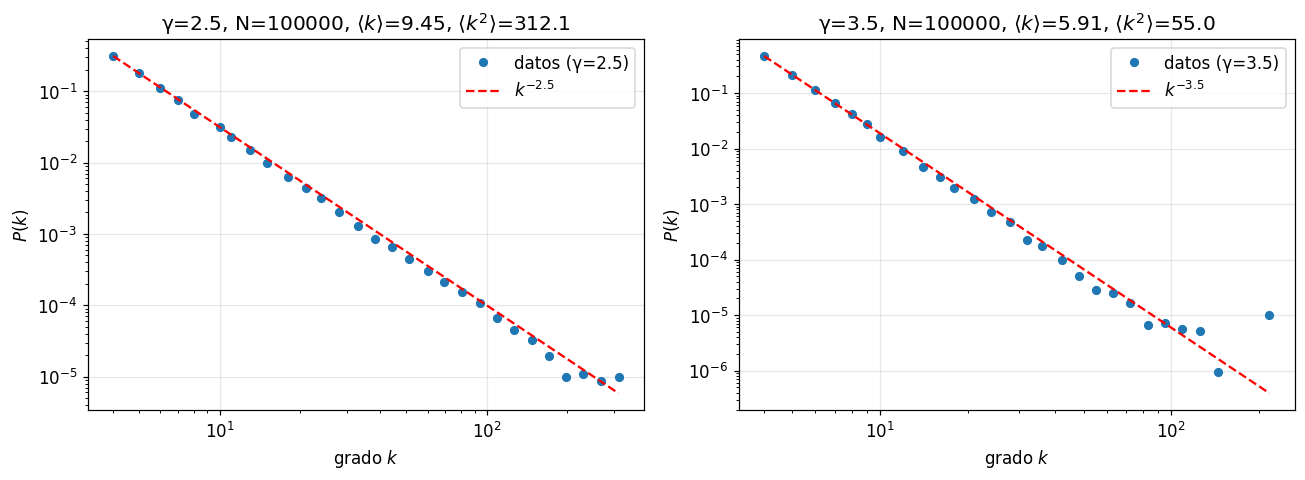

In [6]:
def degree_sequence(gamma, N, net_seed=1000, kmax=None):
    kmax = kmax if kmax is not None else CFG["kmax_fn"](N)
    fn = os.path.join(RESDIR, f"deg_g{gamma}_N{N}_s{net_seed}.txt")
    run_c(N, gamma, [0.05], M=1, cth=CFG["cth"], kmin=CFG["kmin"], kmax=kmax,
          net_seed=net_seed, dyn_seed=1, save_degrees=fn)
    return np.loadtxt(fn, dtype=int)

N_demo = CFG["sizes"][min(3, len(CFG["sizes"])-1)]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, g in zip(axes, CFG["gammas"]):
    deg = degree_sequence(g, N_demo)
    kmax = deg.max()
    bins = np.unique(np.round(np.logspace(np.log10(CFG["kmin"]),
                                          np.log10(kmax), 30)).astype(int))
    h, edges = np.histogram(deg, bins=np.append(bins, bins[-1]+1), density=True)
    centers = bins.astype(float)
    m = h > 0
    ax.loglog(centers[m], h[m], 'o', ms=5, label=f"datos (γ={g})")
    kk = np.logspace(np.log10(CFG["kmin"]), np.log10(kmax), 50)
    ref = kk**(-g); ref *= h[m][0]/ref[np.argmin(abs(kk-centers[m][0]))]
    ax.loglog(kk, ref, 'r--', label=fr"$k^{{-{g}}}$")
    ax.set(xlabel="grado $k$", ylabel="$P(k)$",
           title=fr"γ={g}, N={N_demo}, $\langle k\rangle$={deg.mean():.2f}, $\langle k^2\rangle$={ (deg**2).mean():.1f}")
    ax.legend()
plt.tight_layout(); plt.show()

## Apartado 2 — Método del lifespan: $P_{\rm end}(\lambda,N)$ y $\langle\tau(\lambda,N)\rangle$

Ejecutamos el barrido en $\lambda$ para cada $(\gamma,N)$. El resultado se guarda en el
diccionario `RES[gamma][N]` (un `DataFrame` con columnas `lambda, p_end, tau_mean,
tau2_mean, …`). Gracias a la caché, volver a ejecutar esta celda es inmediato.

## Herramientas de análisis (picos y ajustes)

- `find_peak`: localiza el máximo y lo refina con una **parábola local** (3 puntos),
  devolviendo posición y altura del pico.
- `eq16_fit`: ajuste no lineal de la **Ec. (16)** $\lambda_p(N)=\lambda_c+A\,N^{-1/\nu}$
  (con cotas para estabilizarlo).
- `powerlaw_slope`: pendiente en log–log para los exponentes de altura ($\gamma_n/\nu$)
  y de $P_{\rm end}(\lambda_c,N)$ ($-\beta/\nu$).

In [8]:
def find_peak_smooth(lam, y, yerr, half=2):
    """Suaviza con media móvil ponderada antes de buscar el pico."""
    lam = np.asarray(lam, float)
    y   = np.asarray(y, float)
    yerr = np.where(np.asarray(yerr,float) <= 0, y*0.1, np.asarray(yerr,float))
    
    # suavizado: cada punto es media ponderada de sus vecinos
    y_smooth = np.zeros_like(y)
    for i in range(len(y)):
        lo = max(0, i-half); hi = min(len(y), i+half+1)
        w = 1.0 / yerr[lo:hi]**2
        y_smooth[i] = np.sum(w * y[lo:hi]) / np.sum(w)
    
    # buscar pico en el perfil suavizado
    return find_peak_weighted(lam, y_smooth, yerr, half=half)


def find_peak_weighted(lam, y, yerr, half=2):
    """Localiza el pico usando el máximo del valor menos su error,
    luego refina con parábola ponderada por 1/yerr²."""
    lam = np.asarray(lam, float)
    y   = np.asarray(y, float)
    yerr = np.asarray(yerr, float)
    yerr = np.where(yerr <= 0, y*0.1, yerr)  # evitar división por cero
    
    # índice del máximo de (y - yerr), más robusto al ruido
    i = int(np.argmax(y - yerr))
    lo = max(0, i-half); hi = min(len(lam), i+half+1)
    
    if hi - lo >= 3:
        w = 1.0 / yerr[lo:hi]**2
        try:
            c = np.polyfit(lam[lo:hi], y[lo:hi], 2, w=w)
            if c[0] < 0:
                lp = -c[1] / (2*c[0])
                hp = np.polyval(c, lp)
                if lam[lo] <= lp <= lam[hi-1]:
                    return lp, hp
        except:
            pass
    return lam[i], y[i]



def find_peak(lam, y, half=1):
    lam = np.asarray(lam, float); y = np.asarray(y, float)
    i = int(np.argmax(y)); lo = max(0, i-half); hi = min(len(lam), i+half+1)
    if hi-lo >= 3:
        c = np.polyfit(lam[lo:hi], y[lo:hi], 2)
        if c[0] < 0:
            lp = -c[1]/(2*c[0]); hp = np.polyval(c, lp)
            if lam[lo] <= lp <= lam[hi-1]:
                return lp, hp
    return lam[i], y[i]

def eq16_fit(Ns, LP, sigma=None):
    Ns = np.asarray(Ns, float); LP = np.asarray(LP, float)
    f = lambda N, lc, A, inv_nu: lc + A*N**(-inv_nu)
    p0 = [max(LP.min()-0.005, 1e-4), max(LP.max()-LP.min(), 0.01), 0.4]
    bounds = ([0.0, 0.0, 0.05], [1.0, 50.0, 1.5])
    popt, pcov = curve_fit(f, Ns, LP, p0=p0, bounds=bounds, sigma=sigma,
                           absolute_sigma=sigma is not None, maxfev=300000)
    return popt, np.sqrt(np.diag(pcov))

def powerlaw_slope(Ns, Y, Yerr=None):
    Ns = np.asarray(Ns, float); Y = np.asarray(Y, float)
    m = Y > 0
    if m.sum() < 2:
        return np.nan, np.nan
    x = np.log(Ns[m]); yv = np.log(Y[m])
    w = (Y[m]/np.asarray(Yerr, float)[m]) if Yerr is not None else None
    c, cov = np.polyfit(x, yv, 1, w=w, cov=True)
    return c[0], np.sqrt(cov[0, 0])

print("Funciones de análisis cargadas.")

Funciones de análisis cargadas.


## cálculo de $\lambda_c$ y $\nu$ a partir de los picos

In [ ]:
Ns = np.array(CFG["sizes"], float)
LP = []
col_peak = "tau2_mean"; col_err = "tau2_err"
for N in CFG["sizes"]:
    d = RES[g][N]
    lp, _ = find_peak_weighted(d['lambda'], d[col_peak], d[col_err])
    LP.append(lp)
LP = np.array(LP)

popt, perr = eq16_fit(Ns, LP)
lc, A, inv_nu = popt
print(f"λc = {lc:.5f} ± {perr[0]:.5f}")
print(f"1/ν = {inv_nu:.4f} ± {perr[2]:.4f}")
print(f"ν = {1/inv_nu:.3f}")
print()
for N, lp in zip(CFG["sizes"], LP):
    print(f"N={N:>8d}  λp={lp:.5f}  ajuste={lc + A*N**(-inv_nu):.5f}")

In [208]:
import os
save_dir = "resultados_finales"
os.makedirs(save_dir, exist_ok=True)

# Guardar
for N in CFG["sizes"]:
    if N in RES[3.5]:
        path = os.path.join(save_dir, f"g35_N{N}.csv")
        RES[3.5][N].to_csv(path, index=False)
        print(f"Guardado: {path}  ({len(RES[3.5][N])} puntos)")

Guardado: resultados_finales\g35_N10000.csv  (60 puntos)
Guardado: resultados_finales\g35_N30000.csv  (60 puntos)
Guardado: resultados_finales\g35_N50000.csv  (55 puntos)
Guardado: resultados_finales\g35_N100000.csv  (35 puntos)
Guardado: resultados_finales\g35_N300000.csv  (40 puntos)
Guardado: resultados_finales\g35_N500000.csv  (25 puntos)
Guardado: resultados_finales\g35_N1000000.csv  (40 puntos)


In [209]:
import os
save_dir = "resultados_finales"
os.makedirs(save_dir, exist_ok=True)

# Guardar
for N in CFG["sizes"]:
    if N in RES[2.5]:
        path = os.path.join(save_dir, f"g25_N{N}.csv")
        RES[2.5][N].to_csv(path, index=False)
        print(f"Guardado: {path}  ({len(RES[2.5][N])} puntos)")

Guardado: resultados_finales\g25_N10000.csv  (45 puntos)
Guardado: resultados_finales\g25_N30000.csv  (45 puntos)
Guardado: resultados_finales\g25_N50000.csv  (35 puntos)
Guardado: resultados_finales\g25_N100000.csv  (30 puntos)
Guardado: resultados_finales\g25_N300000.csv  (35 puntos)
Guardado: resultados_finales\g25_N500000.csv  (25 puntos)
Guardado: resultados_finales\g25_N1000000.csv  (25 puntos)


## Apartado 3 — $\langle\tau\rangle$ vs $\lambda$, pico $\lambda_p(N)$ y ajuste de la Ec. (16)

Para cada $\gamma$: (a) graficamos $\langle\tau(\lambda,N)\rangle$ frente a $\lambda$ para
todos los tamaños; (b) localizamos el pico $\lambda_p(N)$; (c) ajustamos la Ec. (16) para
obtener $\lambda_c$ y $1/\nu$. Guardamos los resultados en `FIT[gamma]`.

In [5]:
# Cargar (ejecutar esto tras reiniciar el kernel)

RES = {g: {} for g in CFG["gammas"]}
save_dir = "resultados_finales"
for N in CFG["sizes"]:
    path = os.path.join(save_dir, f"g25_N{N}.csv")
    if os.path.exists(path):
        RES[2.5][N] = pd.read_csv(path)
        print(f"Cargado: N={N}  ({len(RES[2.5][N])} puntos)")
    else:
        print(f"Falta: N={N}")

Cargado: N=10000  (45 puntos)
Cargado: N=30000  (45 puntos)
Cargado: N=50000  (35 puntos)
Cargado: N=100000  (30 puntos)
Cargado: N=300000  (35 puntos)
Cargado: N=500000  (25 puntos)
Cargado: N=1000000  (25 puntos)


In [6]:
# Cargar (ejecutar esto tras reiniciar el kernel)
save_dir = "resultados_finales"
for N in CFG["sizes"]:
    path = os.path.join(save_dir, f"g35_N{N}.csv")
    if os.path.exists(path):
        RES[3.5][N] = pd.read_csv(path)
        print(f"Cargado: N={N}  ({len(RES[3.5][N])} puntos)")
    else:
        print(f"Falta: N={N}")

Cargado: N=10000  (60 puntos)
Cargado: N=30000  (60 puntos)
Cargado: N=50000  (55 puntos)
Cargado: N=100000  (35 puntos)
Cargado: N=300000  (40 puntos)
Cargado: N=500000  (25 puntos)
Cargado: N=1000000  (40 puntos)


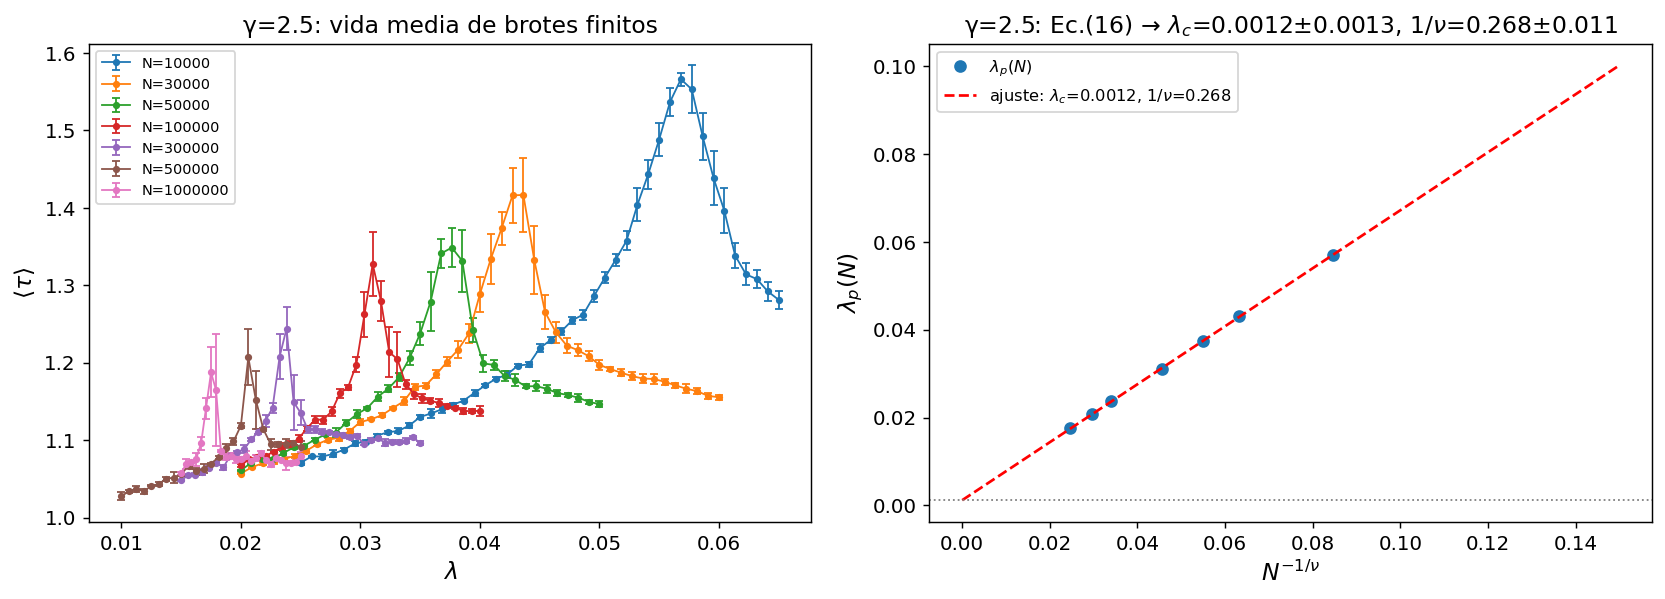

γ=2.5:  λc = 0.00118 ± 0.00125   1/ν = 0.2680 ± 0.0105   (ν = 3.731)



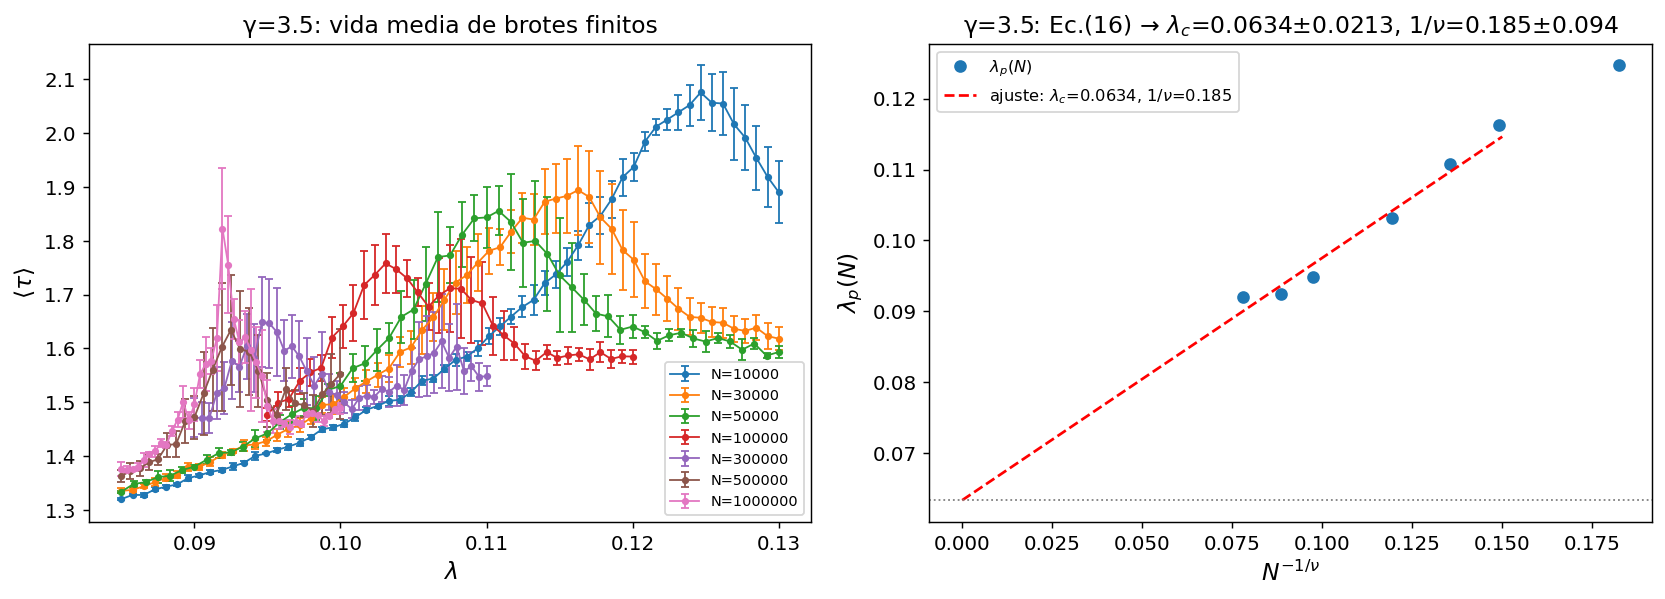

γ=3.5:  λc = 0.06336 ± 0.02131   1/ν = 0.1847 ± 0.0944   (ν = 5.415)



In [210]:
FIT = {}
for g in CFG["gammas"]:
    sizes = CFG["sizes"]
    col_peak = "tau2_mean" 
    col_err  = "tau2_err" 
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
    LP, HP, HP2 = [], [], []
    for N in sizes:
        d = RES[g][N]
        ax[0].errorbar(d['lambda'], d['tau_mean'], yerr=d['tau_err'],
                       marker='o', ms=3, lw=1, capsize=2, label=f"N={N}")
        #lp, hp   = find_peak_weighted(d['lambda'], d['tau_mean'],  d['tau_err'])
        lp, hp   = find_peak(d['lambda'], d['tau_mean'])
        _,  hp2  = find_peak(d['lambda'], d['tau_mean'])
        #_, hp2  = find_peak_weighted(d['lambda'], d['tau_mean'], d['tau_err'])
        LP.append(lp); HP.append(hp); HP2.append(hp2)
    ax[0].set(xlabel=r"$\lambda$", ylabel=r"$\langle\tau\rangle$",
              title=fr"γ={g}: vida media de brotes finitos")
    ax[0].legend(fontsize=8)

    popt, perr = eq16_fit(sizes, LP)
    lc, A, inv_nu = popt
    FIT[g] = dict(lc=lc, lc_err=perr[0], inv_nu=inv_nu, inv_nu_err=perr[2],
                  A=A, LP=np.array(LP), HP=np.array(HP), HP2=np.array(HP2))
    Ns = np.array(sizes, float)
    xx = np.linspace(0, Ns.max()**(-inv_nu)*1.05, 200)
    xx=np.linspace(0, 0.15, 200)
    ax[1].plot(Ns**(-inv_nu), LP, 'o', label=r"$\lambda_p(N)$")
    ax[1].plot(xx, lc + A*xx, 'r--',
               label=fr"ajuste: $\lambda_c$={lc:.4f}, $1/\nu$={inv_nu:.3f}")
    ax[1].axhline(lc, color='gray', ls=':', lw=1)
    ax[1].set(xlabel=r"$N^{-1/\nu}$", ylabel=r"$\lambda_p(N)$",
              title=fr"γ={g}: Ec.(16) → $\lambda_c$={lc:.4f}±{perr[0]:.4f}, "
                    fr"$1/\nu$={inv_nu:.3f}±{perr[2]:.3f}")
    ax[1].legend(fontsize=9)
    plt.tight_layout(); plt.show()
    print(f"γ={g}:  λc = {lc:.5f} ± {perr[0]:.5f}   1/ν = {inv_nu:.4f} ± {perr[2]:.4f}"
          f"   (ν = {1/inv_nu:.3f})\n")

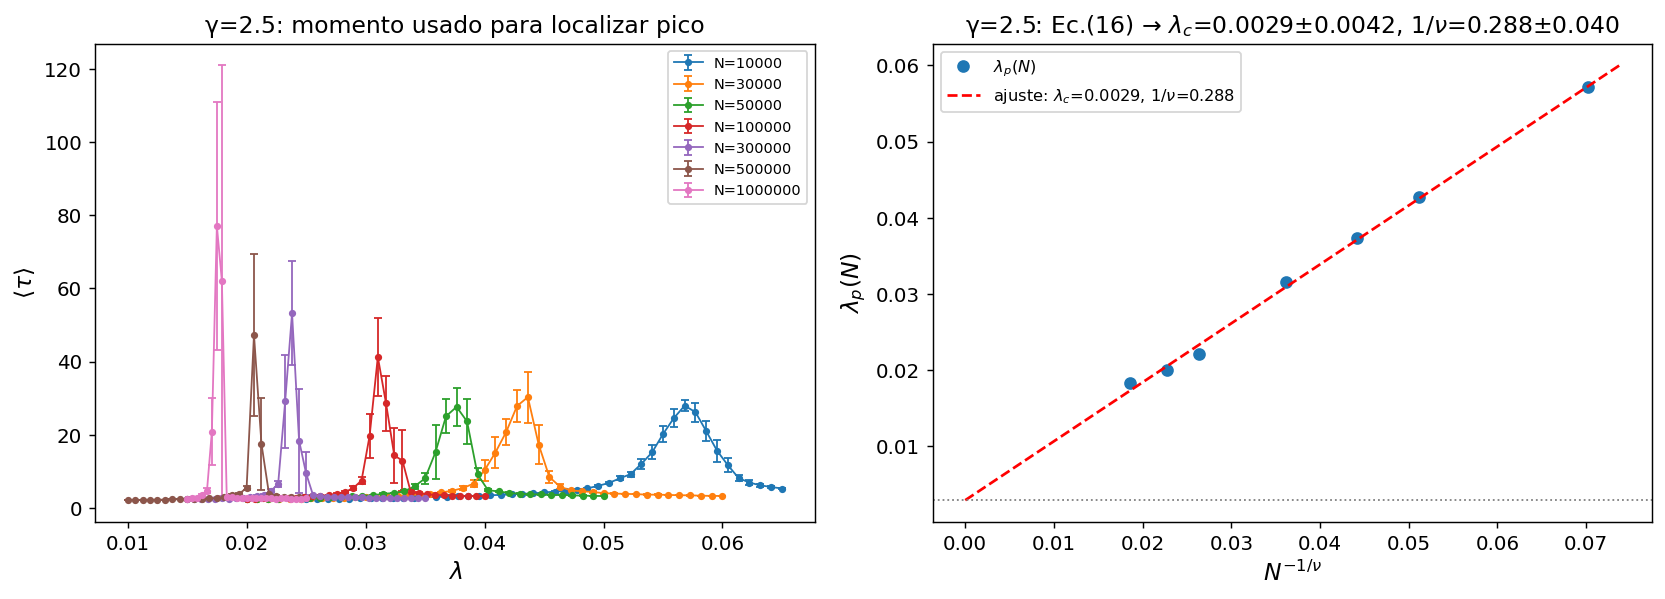

γ=2.5:  λc = 0.00294 ± 0.00416   1/ν = 0.2883 ± 0.0402   (ν = 3.468)



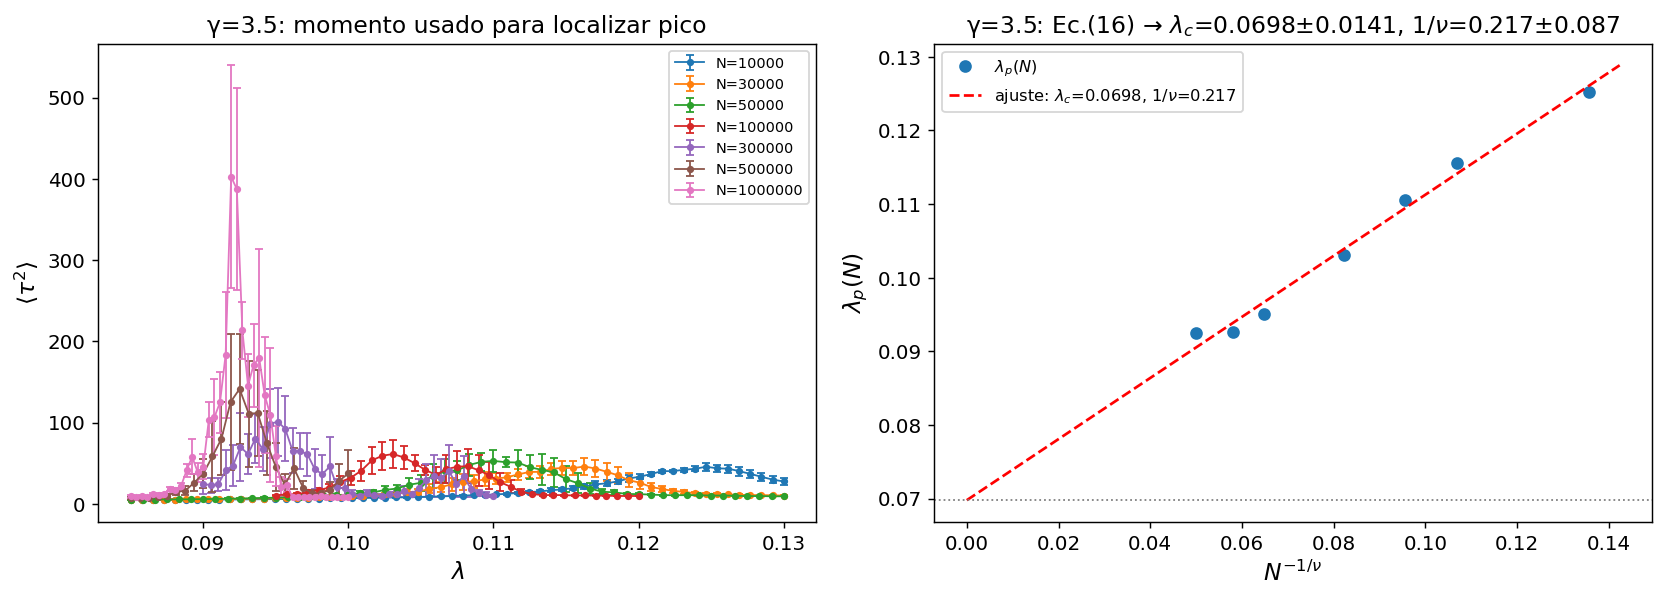

γ=3.5:  λc = 0.06980 ± 0.01407   1/ν = 0.2170 ± 0.0866   (ν = 4.609)
  Nota: incertidumbre grande en λc — convergencia muy lenta para γ>3.
  Referencia de campo medio: <k>/<k²> = 0.10312



In [162]:
FIT = {}
for g in CFG["gammas"]:
    sizes = CFG["sizes"]
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
    LP, HP, HP2 = [], [], []

    # col_peak = "tau2_mean" if g == 3.5 else "tau_mean"
    # col_err  = "tau2_err"  if g == 3.5 else "tau_err"

    col_peak = "tau2_mean" 
    col_err  = "tau2_err" 

    for N in sizes:
        d = RES[g][N]
        lp, _   = find_peak_smooth(d['lambda'], d[col_peak], d[col_err])
        _, hp1  = find_peak(d['lambda'], d['tau_mean'])
        _, hp2  = find_peak_smooth(d['lambda'], d['tau2_mean'], d['tau2_err'])
        LP.append(lp); HP.append(hp1); HP2.append(hp2)
        ax[0].errorbar(d['lambda'], d[col_peak], yerr=d[col_err],
                       marker='o', ms=3, lw=1, capsize=2, label=f"N={N}")

    ax[0].set(xlabel=r"$\lambda$", ylabel=fr"$\langle\tau^2\rangle$" if g==3.5 else r"$\langle\tau\rangle$",
              title=fr"γ={g}: momento usado para localizar pico")
    ax[0].legend(fontsize=8)

    Ns = np.array(sizes, float)
    popt, perr = eq16_fit(Ns, LP)
    lc, A, inv_nu = popt
    FIT[g] = dict(lc=lc, lc_err=perr[0], inv_nu=inv_nu, inv_nu_err=perr[2],
                  A=A, LP=np.array(LP), HP=np.array(HP), HP2=np.array(HP2))

    # eje x del plot: N^{-1/nu}
    xx = np.linspace(0, Ns.min()**(-inv_nu) * 1.05, 200)
    ax[1].plot(Ns**(-inv_nu), LP, 'o', label=r"$\lambda_p(N)$")
    ax[1].plot(xx, lc + A*xx, 'r--',
               label=fr"ajuste: $\lambda_c$={lc:.4f}, $1/\nu$={inv_nu:.3f}")
    ax[1].axhline(lc, color='gray', ls=':', lw=1)
    ax[1].set(xlabel=r"$N^{-1/\nu}$", ylabel=r"$\lambda_p(N)$",
              title=fr"γ={g}: Ec.(16) → $\lambda_c$={lc:.4f}±{perr[0]:.4f}, "
                    fr"$1/\nu$={inv_nu:.3f}±{perr[2]:.3f}")
    ax[1].legend(fontsize=9)
    plt.tight_layout(); plt.show()

    print(f"γ={g}:  λc = {lc:.5f} ± {perr[0]:.5f}   "
          f"1/ν = {inv_nu:.4f} ± {perr[2]:.4f}   (ν = {1/inv_nu:.3f})")
    
    if g == 3.5:
        mk  = RES[g][sizes[-1]]['mean_k'].iloc[0]
        mk2 = RES[g][sizes[-1]]['mean_k2'].iloc[0]
        print(f"  Nota: incertidumbre grande en λc — convergencia muy lenta para γ>3.")
        print(f"  Referencia de campo medio: <k>/<k²> = {mk/mk2:.5f}")
    print()

C:\Users\anica\AppData\Local\Temp\ipykernel_28168\455444014.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  CMAP  = plt.cm.get_cmap("Set2", len(SIZES))


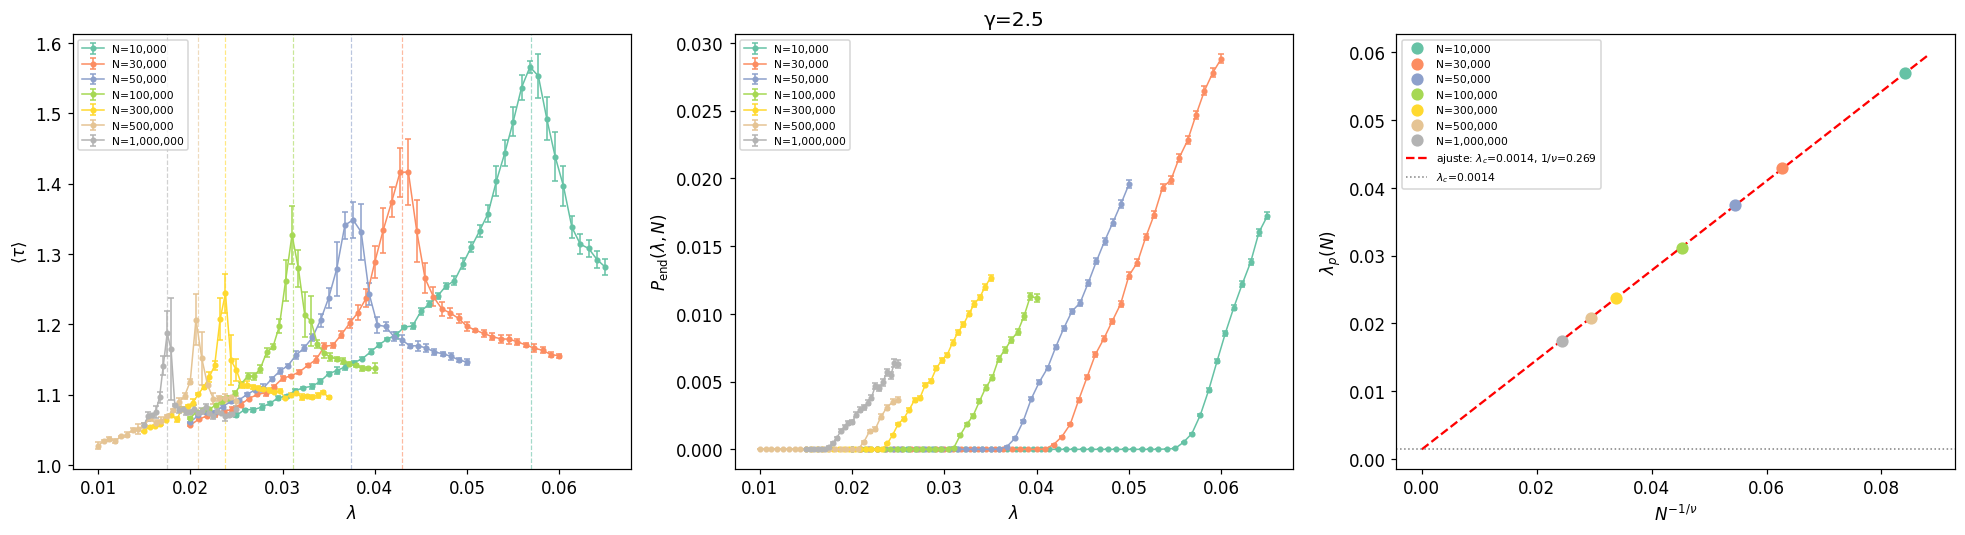

γ=2.5:  λc = 0.00140 ± 0.00080   1/ν = 0.2688 ± 0.0068   (ν = 3.721)



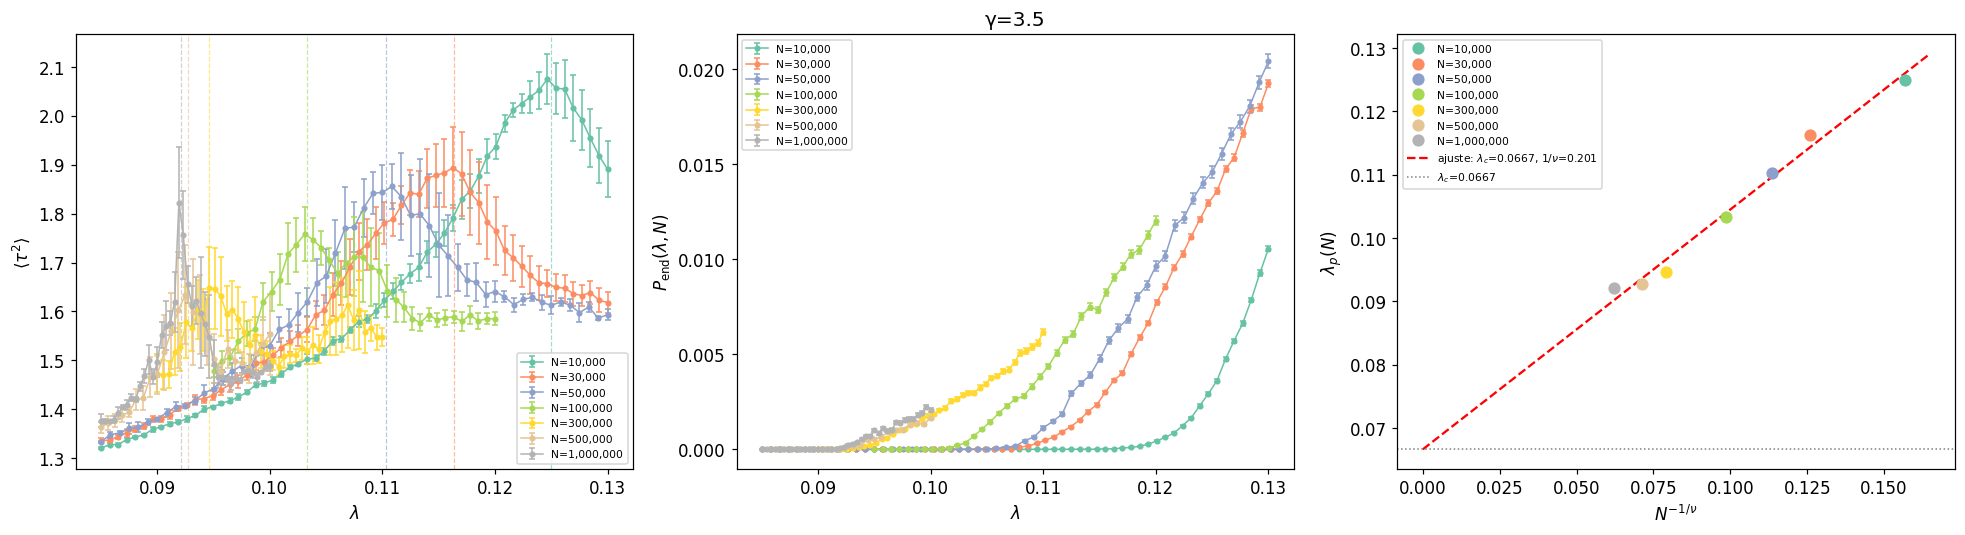

γ=3.5:  λc = 0.06666 ± 0.01790   1/ν = 0.2011 ± 0.0938   (ν = 4.972)
  Nota: convergencia lenta para γ>3. Referencia campo medio: <k>/<k²> = 0.10312



In [9]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Paleta consistente para todo el report
SIZES = CFG["sizes"]
CMAP  = plt.cm.get_cmap("Set2", len(SIZES))
COLORS = {N: CMAP(i) for i, N in enumerate(SIZES)}

FIT = {}
for g in CFG["gammas"]:
    sizes = CFG["sizes"]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    ax0, ax1, ax2 = axes
    LP, HP, HP2 = [], [], []

    col_peak = "tau_mean" if g == 3.5 else "tau_mean"
    col_err  = "tau_err"  if g == 3.5 else "tau_err"
    ylabel0  = r"$\langle\tau^2\rangle$" if g == 3.5 else r"$\langle\tau\rangle$"

    for N in sizes:
        d = RES[g][N]
        c = COLORS[N]

        # filtro lambda minimo
        lam_min = 0.09 if g == 3.5 else 0.0
        lam_max=0.1 if (g==3.5 and N==500000) else 1.0
        mask = (d['lambda'].values >= lam_min) & (d['lambda'].values <= lam_max)
        d_filt = d[mask].reset_index(drop=True)

        lp, _  = find_peak_weighted(d_filt['lambda'], d_filt[col_peak], d_filt[col_err])
        _, hp1 = find_peak(d_filt['lambda'], d_filt['tau_mean'])
        # _, hp2 = find_peak_weighted(d_filt['lambda'], d_filt['tau2_mean'], d_filt['tau2_err'])
        _, hp2 = find_peak(d_filt['lambda'], d_filt['tau2_mean'])
        LP.append(lp); HP.append(hp1); HP2.append(hp2)

        # panel izquierdo: tau o tau2
        ax0.errorbar(d['lambda'], d[col_peak], yerr=d[col_err],
                     color=c, marker='o', ms=3, lw=1, capsize=2, label=f"N={N:,}")
        ax0.axvline(lp, color=c, ls='--', lw=0.8, alpha=0.6)

        # panel central: Pend
        ax1.errorbar(d['lambda'], d['p_end'], yerr=d['p_end_err'],
                     color=c, marker='o', ms=3, lw=1, capsize=2, label=f"N={N:,}")

    ax0.set(xlabel=r"$\lambda$", ylabel=ylabel0)
    ax0.legend(fontsize=7)

    ax1.set(xlabel=r"$\lambda$", ylabel=r"$P_{\rm end}(\lambda,N)$",
            title=fr"γ={g}")
    ax1.legend(fontsize=7)

    ax0.grid(False)
    ax1.grid(False)

    # panel derecho: ajuste Ec.(16)
    Ns = np.array(sizes, float)
    popt, perr = eq16_fit(Ns, LP)
    lc, A, inv_nu = popt
    FIT[g] = dict(lc=lc, lc_err=perr[0], inv_nu=inv_nu, inv_nu_err=perr[2],
                  A=A, LP=np.array(LP), HP=np.array(HP), HP2=np.array(HP2))

    xx = np.linspace(0, Ns.min()**(-inv_nu) * 1.05, 200)
    for N, lp in zip(sizes, LP):
        ax2.plot(N**(-inv_nu), lp, 'o', color=COLORS[N], ms=7, label=f"N={N:,}", zorder=3)
    ax2.plot(xx, lc + A*xx, 'r--',
             label=fr"ajuste: $\lambda_c$={lc:.4f}, $1/\nu$={inv_nu:.3f}")
    ax2.axhline(lc, color='gray', ls=':', lw=1, label=fr"$\lambda_c$={lc:.4f}")
    # ax2.set(xlabel=r"$N^{-1/\nu}$", ylabel=r"$\lambda_p(N)$",
    #         title=fr"γ={g}: Ec.(16) → $\lambda_c$={lc:.4f}±{perr[0]:.4f}, "
    #               fr"$1/\nu$={inv_nu:.3f}±{perr[2]:.3f}")
    ax2.set(xlabel=r"$N^{-1/\nu}$", ylabel=r"$\lambda_p(N)$")
    ax2.legend(fontsize=7)

    #plt.suptitle(fr"Apartado 3 — γ={g}", fontsize=13, y=1.01)
    plt.grid(False)
    plt.tight_layout()
    plt.savefig(f"resultados_finales/ap3_g{str(g).replace('.','')}.pdf",
                bbox_inches='tight')
    plt.show()

    print(f"γ={g}:  λc = {lc:.5f} ± {perr[0]:.5f}   "
          f"1/ν = {inv_nu:.4f} ± {perr[2]:.4f}   (ν = {1/inv_nu:.3f})")
    if g == 3.5:
        mk  = RES[g][sizes[-1]]['mean_k'].iloc[0]
        mk2 = RES[g][sizes[-1]]['mean_k2'].iloc[0]
        print(f"  Nota: convergencia lenta para γ>3. "
              f"Referencia campo medio: <k>/<k²> = {mk/mk2:.5f}")
    print()

## Apartado 4 — Altura del pico de $\langle\tau\rangle$ vs $N$ → $\gamma_1/\nu$

La altura del pico crece como $\langle\tau\rangle_p\sim N^{\gamma_1/\nu}$. Recordando el
**caso $\delta=1$** (campo medio, esperado para $\gamma>3$): si $\langle\tau\rangle$ sólo
crece logarítmicamente, su exponente será $\approx0$ y mal definido; por eso medimos
también $\langle\tau^2\rangle_p\sim N^{\gamma_2/\nu}$, como recomienda la Ref. [1].

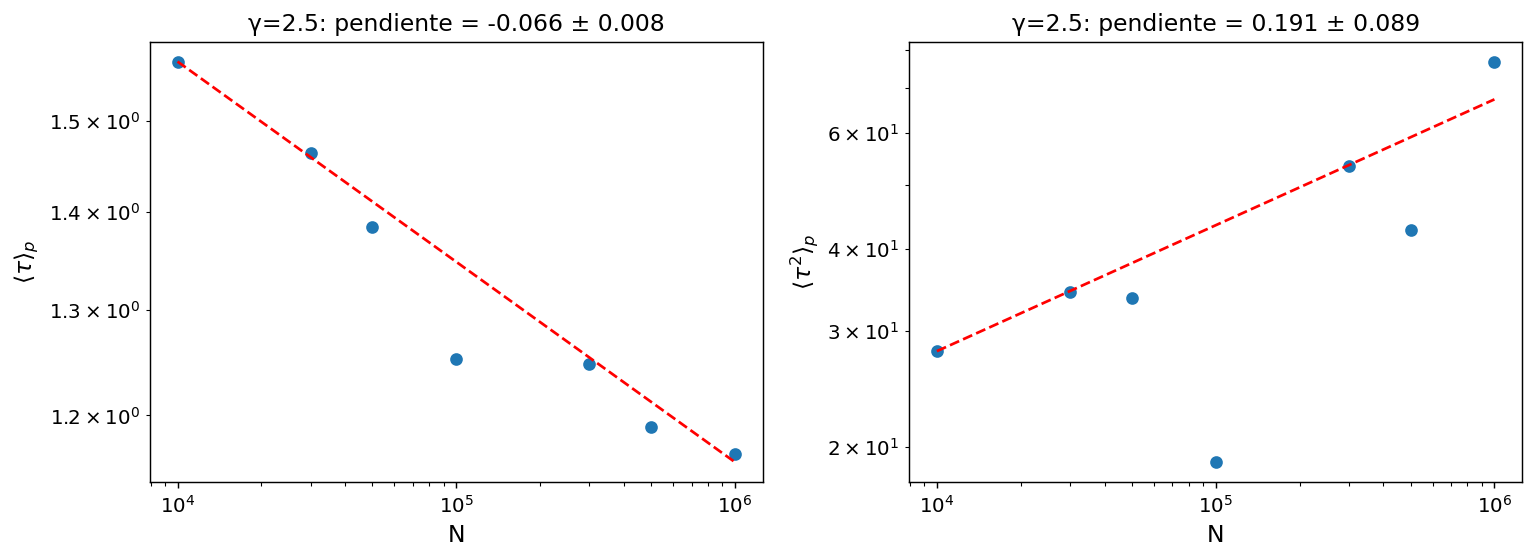

γ=2.5:  γ1/ν (de <τ>)   = -0.0659 ± 0.0075   (≈0 → caso δ≈1)
        γ2/ν (de <τ²>) = 0.1912 ± 0.0885



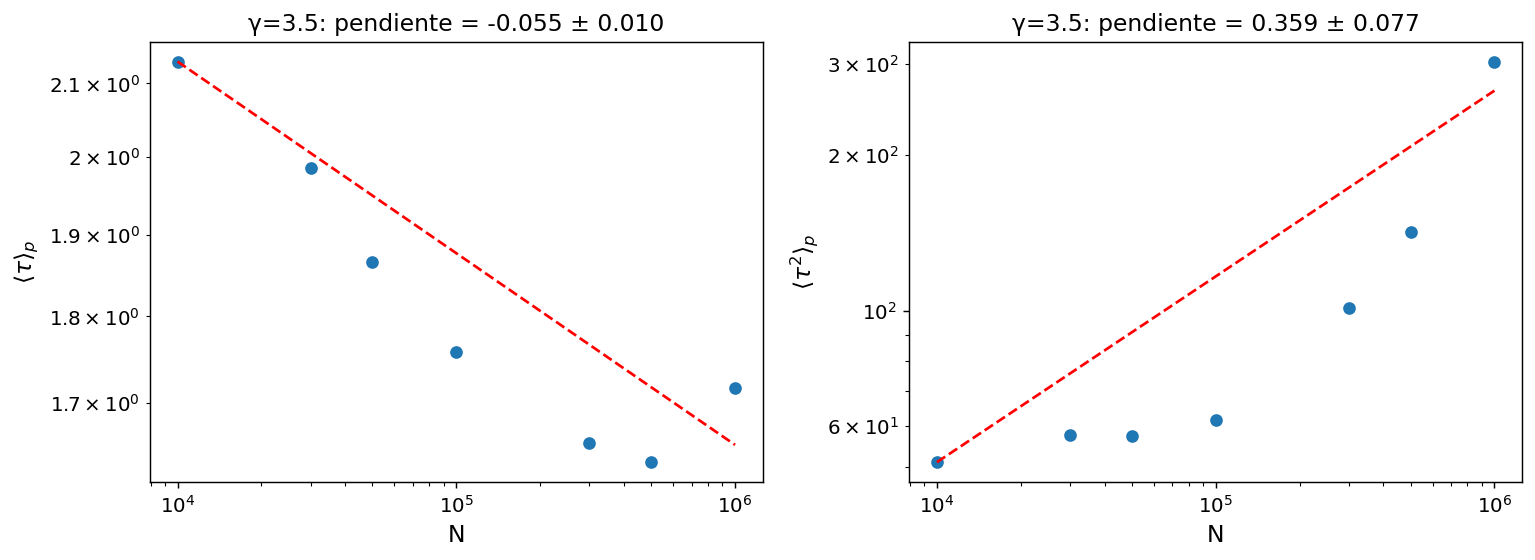

γ=3.5:  γ1/ν (de <τ>)   = -0.0550 ± 0.0104   (≈0 → caso δ≈1)
        γ2/ν (de <τ²>) = 0.3586 ± 0.0766



In [109]:
for g in CFG["gammas"]:
    Ns = np.array(CFG["sizes"], float)
    HP, HP2 = FIT[g]["HP"], FIT[g]["HP2"]
    s1, e1 = powerlaw_slope(Ns, HP)
    s2, e2 = powerlaw_slope(Ns, HP2)
    FIT[g].update(g1_nu=s1, g1_nu_err=e1, g2_nu=s2, g2_nu_err=e2)

    fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
    for a, (Y, s, e, lab) in zip(ax, [(HP, s1, e1, r"\langle\tau\rangle"),
                                      (HP2, s2, e2, r"\langle\tau^2\rangle")]):
        a.loglog(Ns, Y, 'o', ms=6)
        if np.isfinite(s):
            a.loglog(Ns, np.exp(np.polyval([s, np.log(Y[Y>0][0])-s*np.log(Ns[Y>0][0])],
                                            np.log(Ns))), 'r--')
        a.set(xlabel="N", ylabel=fr"${lab}_p$",
              title=fr"γ={g}: pendiente = {s:.3f} ± {e:.3f}")
    plt.tight_layout(); plt.show()
    print(f"γ={g}:  γ1/ν (de <τ>)   = {s1:.4f} ± {e1:.4f}   "
          f"{'(≈0 → caso δ≈1)' if abs(s1)<0.1 else ''}")
    print(f"        γ2/ν (de <τ²>) = {s2:.4f} ± {e2:.4f}\n")

γ=2.5:  γ1/ν=-0.0587±0.0049   γ2/ν=0.2182±0.0416
γ=3.5:  γ1/ν=-0.0383±0.0144   γ2/ν=0.4425±0.0983


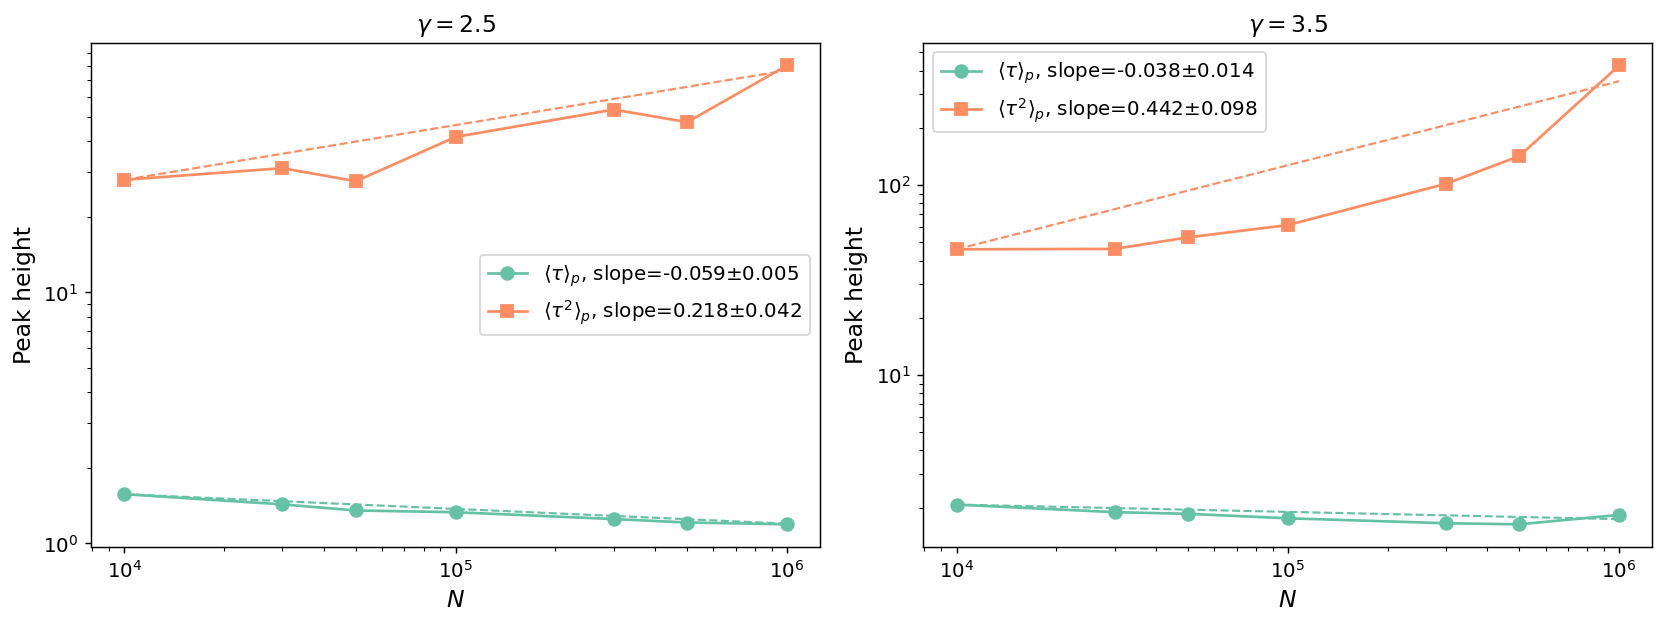

In [14]:
plt.rcParams.update({
    "figure.dpi":        130,
    "font.size":         13,
    "axes.titlesize":    13,
    "axes.labelsize":    13,
    "xtick.labelsize":   11,
    "ytick.labelsize":   11,
    "legend.fontsize":   11,
    "axes.grid":         False,
    "figure.figsize":    (7, 4.5),
})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, g in zip(axes, CFG["gammas"]):
    Ns  = np.array(CFG["sizes"], float)
    HP  = FIT[g]["HP"]
    HP2 = FIT[g]["HP2"]

    g1_nu, e1 = powerlaw_slope(Ns, HP)
    g2_nu, e2 = powerlaw_slope(Ns, HP2)
    FIT[g].update(g1_nu=g1_nu, g1_nu_err=e1, g2_nu=g2_nu, g2_nu_err=e2)

    def powerlaw_line(Ns, Y, slope):
        m = Y > 0
        logA = np.log(Y[m][0]) - slope * np.log(Ns[m][0])
        return np.exp(logA + slope * np.log(Ns))

    ax.loglog(Ns, HP,  'o-', color=COLORS[10000],  ms=7, lw=1.5,
              label=fr"$\langle\tau\rangle_p$, slope={g1_nu:.3f}±{e1:.3f}")
    if np.isfinite(g1_nu):
        ax.loglog(Ns, powerlaw_line(Ns, HP, g1_nu),
                  '--', color=COLORS[10000], lw=1.2)

    ax.loglog(Ns, HP2, 's-', color=COLORS[30000], ms=7, lw=1.5,
              label=fr"$\langle\tau^2\rangle_p$, slope={g2_nu:.3f}±{e2:.3f}")
    if np.isfinite(g2_nu):
        ax.loglog(Ns, powerlaw_line(Ns, HP2, g2_nu),
                  '--', color=COLORS[30000], lw=1.2)

    ax.set(xlabel="$N$", ylabel="Peak height",
           title=fr"$\gamma={g}$")
    ax.legend()

    print(f"γ={g}:  γ1/ν={g1_nu:.4f}±{e1:.4f}   γ2/ν={g2_nu:.4f}±{e2:.4f}")

plt.tight_layout()
plt.savefig("resultados_finales/ap4.pdf", bbox_inches='tight')
plt.show()

## Apartado 5 — $P_{\rm end}(\lambda_c,N)$ vs $N$ → $\beta/\nu$ (Ec. 18)

$P_{\rm end}(\lambda_c,N)\propto N^{-\beta/\nu}$. Para medirlo con precisión hacemos una
**tanda dedicada exactamente en $\lambda=\lambda_c$** (el valor ajustado en el apartado 3)
con la misma estadística, para cada tamaño. Esto evita el ruido de interpolar sobre la
rejilla.

  γ=2.5  N=   10000  <k>=8.676  <k²>=161.64  λc_MF≈0.0537
  γ=2.5  N=   30000  <k>=9.095  <k²>=221.40  λc_MF≈0.0411
  γ=2.5  N=   50000  <k>=9.261  <k²>=255.02  λc_MF≈0.0363
  γ=2.5  N=  100000  <k>=9.451  <k²>=309.45  λc_MF≈0.0305
  γ=2.5  N=  300000  <k>=9.717  <k²>=417.00  λc_MF≈0.0233
  γ=2.5  N=  500000  <k>=9.835  <k²>=479.52  λc_MF≈0.0205
  γ=2.5  N= 1000000  <k>=9.954  <k²>=574.49  λc_MF≈0.0173


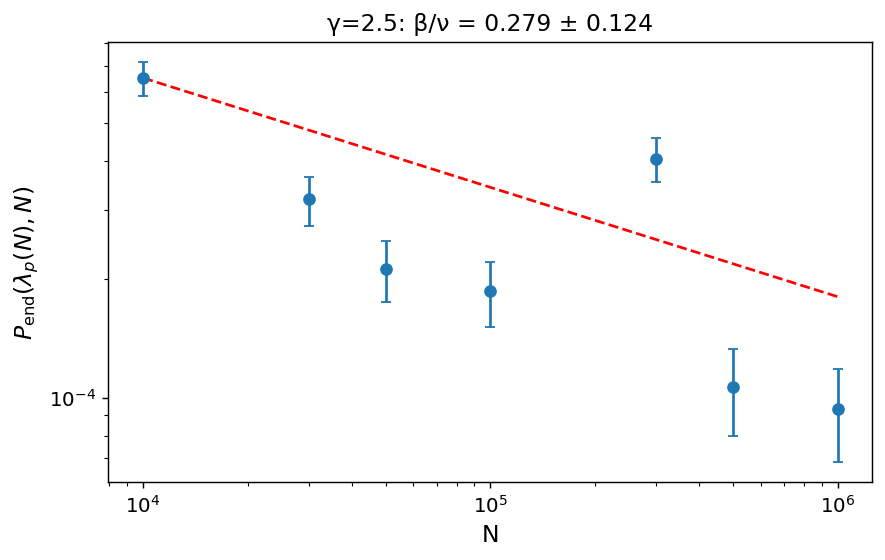

γ=2.5:  Pend(λp,N) = [6.5e-04 3.2e-04 2.1e-04 1.9e-04 4.1e-04 1.1e-04 9.0e-05]
        β/ν = 0.2790 ± 0.1240

  γ=3.5  N=   10000  <k>=5.896  <k²>=51.05  λc_MF≈0.1155
  γ=3.5  N=   30000  <k>=5.904  <k²>=53.18  λc_MF≈0.1110
  γ=3.5  N=   50000  <k>=5.910  <k²>=54.51  λc_MF≈0.1084
  γ=3.5  N=  100000  <k>=5.910  <k²>=55.29  λc_MF≈0.1069
  γ=3.5  N=  300000  <k>=5.915  <k²>=56.42  λc_MF≈0.1048
  γ=3.5  N=  500000  <k>=5.921  <k²>=57.05  λc_MF≈0.1038
  γ=3.5  N= 1000000  <k>=5.923  <k²>=57.43  λc_MF≈0.1031


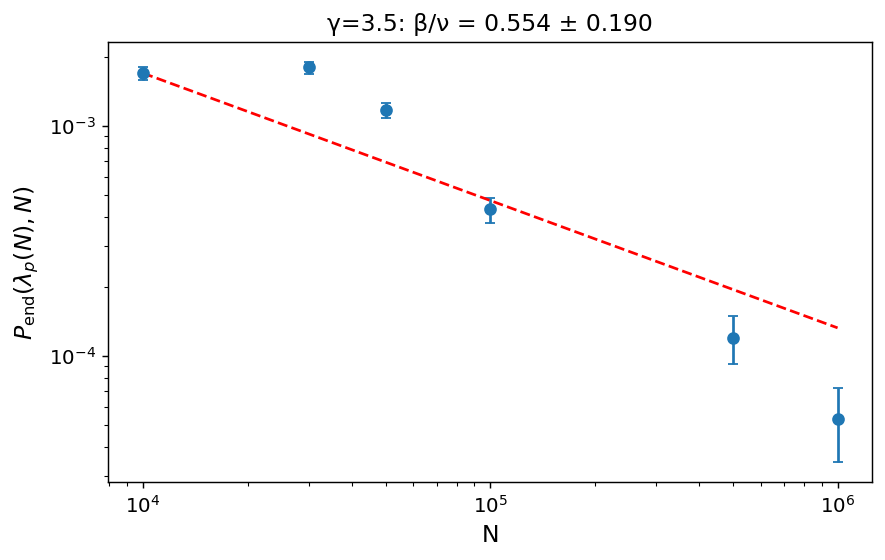

γ=3.5:  Pend(λp,N) = [1.69e-03 1.79e-03 1.17e-03 4.30e-04 0.00e+00 1.20e-04 5.00e-05]
        β/ν = 0.5536 ± 0.1904



In [165]:
for g in CFG["gammas"]:
    lc   = FIT[g]["lc"]
    LP   = FIT[g]["LP"]          # λp(N) para cada tamaño
    Ns   = np.array(CFG["sizes"], float)
    Pc, Pc_err = [], []
    for i, N in enumerate(CFG["sizes"]):
        d = sweep(g, N, [LP[i]], tag="atLp")
        Pc.append(float(d['p_end'].iloc[0]))
        Pc_err.append(float(d['p_end_err'].iloc[0]))
    Pc = np.array(Pc); Pc_err = np.array(Pc_err)
    slope, serr = powerlaw_slope(Ns, Pc, Pc_err)
    FIT[g].update(beta_nu=-slope, beta_nu_err=serr, Pc=Pc, Pc_err=Pc_err)

    plt.figure()
    plt.errorbar(Ns, Pc, yerr=Pc_err, fmt='o', ms=6, capsize=3)
    m = Pc > 0
    if np.isfinite(slope) and m.sum() >= 2:
        plt.loglog(Ns[m], np.exp(np.polyval(
            [slope, np.log(Pc[m][0]) - slope*np.log(Ns[m][0])],
            np.log(Ns[m]))), 'r--')
    plt.xscale('log'); plt.yscale('log')
    plt.xlabel("N"); plt.ylabel(r"$P_{\rm end}(\lambda_p(N),N)$")
    plt.title(fr"γ={g}: β/ν = {-slope:.3f} ± {serr:.3f}")
    plt.tight_layout(); plt.show()
    print(f"γ={g}:  Pend(λp,N) = {np.round(Pc,5)}")
    print(f"        β/ν = {-slope:.4f} ± {serr:.4f}\n")

In [166]:
for g in CFG["gammas"]:
    print(f"γ={g}:")
    print(f"  LP  = {np.round(FIT[g]['LP'], 5)}")
    print(f"  Pc  = {np.round(FIT[g]['Pc'], 6)}")
    print(f"  β/ν = {FIT[g]['beta_nu']:.4f} ± {FIT[g]['beta_nu_err']:.4f}")

γ=2.5:
  LP  = [0.05692 0.0429  0.03744 0.0311  0.0238  0.02085 0.01747]
  Pc  = [6.53e-04 3.20e-04 2.13e-04 1.87e-04 4.07e-04 1.07e-04 9.30e-05]
  β/ν = 0.2790 ± 0.1240
γ=3.5:
  LP  = [0.12499 0.11632 0.11032 0.10327 0.09462 0.09271 0.09214]
  Pc  = [1.693e-03 1.793e-03 1.167e-03 4.330e-04 0.000e+00 1.200e-04 5.300e-05]
  β/ν = 0.5536 ± 0.1904


In [11]:
for g in CFG["gammas"]:
    lc   = FIT[g]["lc"]
    LP   = FIT[g]["LP"]
    Ns   = np.array(CFG["sizes"], float)
    Pc, Pc_err = [], []
    for i, N in enumerate(CFG["sizes"]):
        # evaluar en λp(N) interpolando sobre los datos ya calculados
        d = RES[g][N]
        p    = float(np.interp(LP[i], d['lambda'].values, d['p_end'].values))
        perr = float(np.interp(LP[i], d['lambda'].values, d['p_end_err'].values))
        Pc.append(p); Pc_err.append(perr)
    Pc = np.array(Pc); Pc_err = np.array(Pc_err)
    slope, serr = powerlaw_slope(Ns, Pc, Pc_err)
    FIT[g].update(beta_nu=-slope, beta_nu_err=serr, Pc=Pc, Pc_err=Pc_err)
    print(f"γ={g}:  Pc={np.round(Pc,6)}  β/ν={-slope:.4f}±{serr:.4f}")

γ=2.5:  Pc=[0.001318 0.001114 0.000675 0.000227 0.000422 0.000191 0.000174]  β/ν=0.4351±0.0850
γ=3.5:  Pc=[3.223e-03 3.654e-03 1.262e-03 4.320e-04 2.200e-04 1.280e-04 9.000e-05]  β/ν=0.5143±0.2548


In [168]:
for g in CFG["gammas"]:
    Ns  = np.array(CFG["sizes"], float)
    Pc  = FIT[g]["Pc"]
    Pc_err = FIT[g]["Pc_err"]
    
    mask = Ns >= 100_000
    slope, serr = powerlaw_slope(Ns[mask], Pc[mask], Pc_err[mask])
    FIT[g].update(beta_nu=-slope, beta_nu_err=serr)
    print(f"γ={g}:  β/ν={-slope:.4f}±{serr:.4f}")
    print(f"  Pc usados:  {np.round(Pc[mask],6)}")
    print(f"  Ns usados:  {Ns[mask].astype(int)}")

γ=2.5:  β/ν=0.1067±0.4112
  Pc usados:  [0.000227 0.000422 0.000191 0.000174]
  Ns usados:  [ 100000  300000  500000 1000000]
γ=3.5:  β/ν=0.6852±0.0495
  Pc usados:  [4.32e-04 2.20e-04 1.28e-04 9.00e-05]
  Ns usados:  [ 100000  300000  500000 1000000]


In [169]:
for g in CFG["gammas"]:
    Ns  = np.array(CFG["sizes"], float)
    Pc  = FIT[g]["Pc"]
    Pc_err = FIT[g]["Pc_err"]
    
    # excluir outliers manualmente
    if g == 2.5:
        mask = (Ns >= 100_000) & (Ns != 300_000)
    else:
        mask = Ns >= 100_000
    
    if mask.sum() >= 3:
        slope, serr = powerlaw_slope(Ns[mask], Pc[mask], Pc_err[mask])
    else:
        c = np.polyfit(np.log(Ns[mask]), np.log(Pc[mask]), 1)
        slope, serr = c[0], np.nan
    
    FIT[g].update(beta_nu=-slope, beta_nu_err=serr)
    print(f"γ={g}:  β/ν={-slope:.4f}±{str(round(serr,4)) if np.isfinite(serr) else 'n/a'}")
    print(f"  Pc: {np.round(Pc[mask],6)}  Ns: {Ns[mask].astype(int)}")

γ=2.5:  β/ν=0.1102±0.0067
  Pc: [0.000227 0.000191 0.000174]  Ns: [ 100000  500000 1000000]
γ=3.5:  β/ν=0.6852±0.0495
  Pc: [4.32e-04 2.20e-04 1.28e-04 9.00e-05]  Ns: [ 100000  300000  500000 1000000]


In [171]:
# γ=2.5: probar con N>=50k excluyendo solo el outlier de 300k
g = 2.5
Ns  = np.array(CFG["sizes"], float)
Pc  = FIT[g]["Pc"]
Pc_err = FIT[g]["Pc_err"]

for mask_name, mask in [
    ("N>=100k, sin 300k", (Ns>=100_000) & (Ns!=300_000)),
    ("N>=50k,  sin 300k", (Ns>= 50_000) & (Ns!=300_000)),
    ("N>=50k,  todos",    (Ns>= 50_000)),
]:
    if mask.sum() >= 3:
        s, e = powerlaw_slope(Ns[mask], Pc[mask], Pc_err[mask])
        print(f"{mask_name}: β/ν={-s:.4f}±{e:.4f}  "
              f"Pc={np.round(Pc[mask],6)}  Ns={Ns[mask].astype(int)}")

N>=100k, sin 300k: β/ν=0.1102±0.0067  Pc=[0.000227 0.000191 0.000174]  Ns=[ 100000  500000 1000000]
N>=50k,  sin 300k: β/ν=0.5130±0.1826  Pc=[0.000675 0.000227 0.000191 0.000174]  Ns=[  50000  100000  500000 1000000]
N>=50k,  todos: β/ν=0.3886±0.1787  Pc=[0.000675 0.000227 0.000422 0.000191 0.000174]  Ns=[  50000  100000  300000  500000 1000000]


γ=2.5:  β/ν=0.4351±0.0850
γ=3.5:  β/ν=0.5143±0.2548


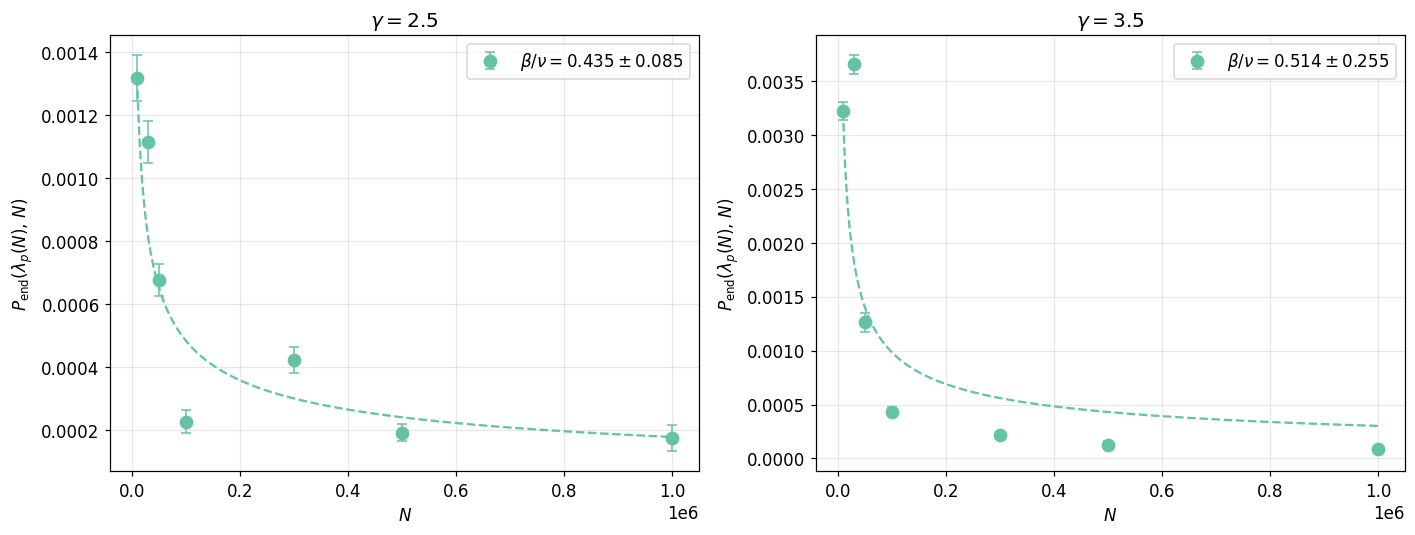

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
C1 = plt.cm.Set2(0)

masks = {
    2.5: (np.array(CFG["sizes"], float) >= 10000) & (np.array(CFG["sizes"], float) != 00000),
    3.5:  (np.array(CFG["sizes"], float) >= 10000) & (np.array(CFG["sizes"], float) != 00000),
}

# Actualizar FIT con los exponentes correctos
for g in CFG["gammas"]:
    Ns     = np.array(CFG["sizes"], float)
    Pc     = FIT[g]["Pc"]
    Pc_err = FIT[g]["Pc_err"]
    mask   = masks[g]
    slope, serr = powerlaw_slope(Ns[mask], Pc[mask], Pc_err[mask])
    FIT[g].update(beta_nu=-slope, beta_nu_err=serr)
    print(f"γ={g}:  β/ν={-slope:.4f}±{serr:.4f}")

# Graficar
for ax, g in zip(axes, CFG["gammas"]):
    Ns     = np.array(CFG["sizes"], float)
    Pc     = FIT[g]["Pc"]
    Pc_err = FIT[g]["Pc_err"]
    bnu    = FIT[g]["beta_nu"]
    berr   = FIT[g]["beta_nu_err"]
    mask   = masks[g]   # <-- recalculado para cada g

    ax.errorbar(Ns[~mask], Pc[~mask], yerr=Pc_err[~mask],
                fmt='o', color=C1, ms=8, mfc='none', capsize=3, lw=1)
    ax.errorbar(Ns[mask], Pc[mask], yerr=Pc_err[mask],
                fmt='o', color=C1, ms=8, capsize=3, lw=1,
                label=fr"$\beta/\nu={bnu:.3f}\pm{berr:.3f}$")
    if np.isfinite(bnu):
        logA  = np.log(Pc[mask][0]) + bnu*np.log(Ns[mask][0])
        Nplot = np.logspace(np.log10(Ns[mask][0]), np.log10(Ns[mask][-1]), 100)
        ax.plot(Nplot, np.exp(logA - bnu*np.log(Nplot)),
                  '--', color=C1, lw=1.5)
    #ax.set_xscale('log'); ax.set_yscale('log')
    ax.set(xlabel="$N$", ylabel=r"$P_{\rm end}(\lambda_p(N),\,N)$",
           title=fr"$\gamma={g}$")
    ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig("resultados_finales/ap5.pdf", bbox_inches='tight')
plt.show()

## Apartado 6 — Curvas de colapso

Usando $\lambda_c$, $1/\nu$, $\beta/\nu$ y $\gamma_1/\nu$ (o $\gamma_2/\nu$),
comprobamos las formas de FSS:
$$N^{\beta/\nu}P_{\rm end}(\lambda,N)=f\big[(\lambda-\lambda_c)N^{1/\nu}\big],\qquad
N^{-\gamma_n/\nu}\langle\tau^n\rangle=G_n\big[(\lambda-\lambda_c)N^{1/\nu}\big].$$
Un buen colapso de las curvas de todos los tamaños sobre una única función valida los
exponentes y $\lambda_c$.

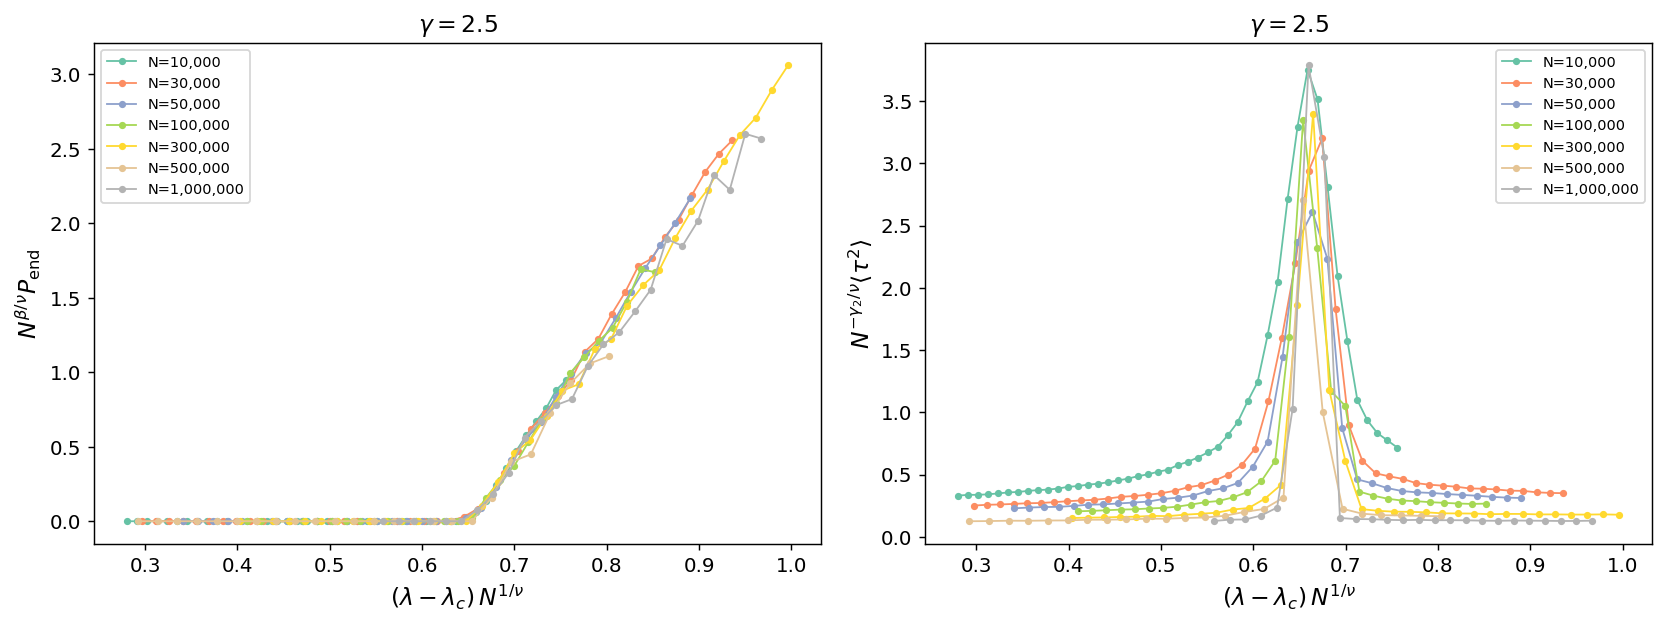

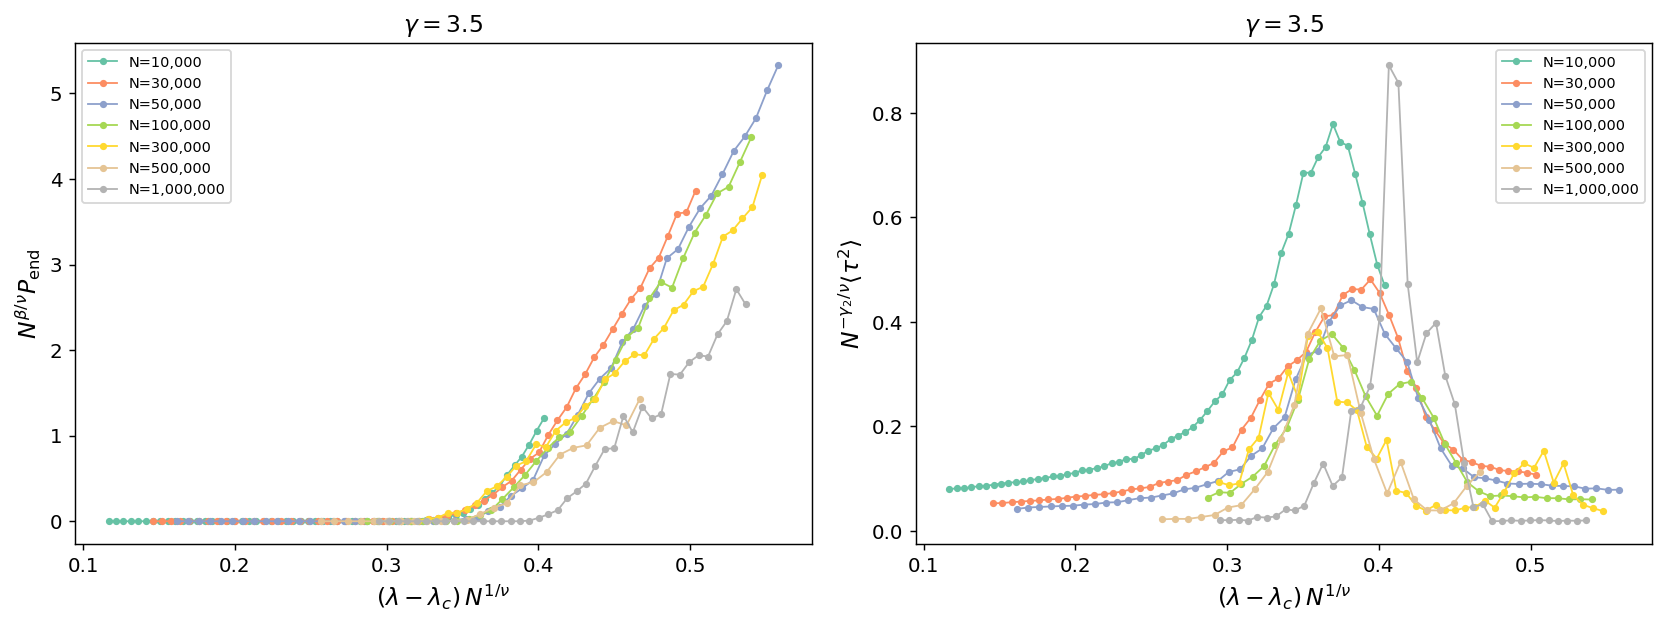

In [15]:
for g in CFG["gammas"]:
    p      = FIT[g]
    lc     = p["lc"]
    inv_nu = p["inv_nu"]
    bnu    = p["beta_nu"]
    gn     = p["g2_nu"]

    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    for N in CFG["sizes"]:
        d = RES[g][N]
        c = COLORS[N]
        x  = (d['lambda'].values - lc) * N**inv_nu
        # limitar rango x para no mostrar ruido lejos del pico
        m  = (x > -2) & (x < 5)
        ax[0].plot(x[m], N**( bnu) * d['p_end'].values[m],
                   'o-', ms=3, lw=1, color=c, label=f"N={N:,}")
        ax[1].plot(x[m], N**(-gn)  * d['tau2_mean'].values[m],
                   'o-', ms=3, lw=1, color=c, label=f"N={N:,}")

    ax[0].set(xlabel=r"$(\lambda-\lambda_c)\,N^{1/\nu}$",
              ylabel=r"$N^{\beta/\nu}P_{\rm end}$",
              title=fr"$\gamma={g}$")
    ax[1].set(xlabel=r"$(\lambda-\lambda_c)\,N^{1/\nu}$",
              ylabel=r"$N^{-\gamma_2/\nu}\langle\tau^2\rangle$",
              title=fr"$\gamma={g}$")
    for a in ax: a.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(f"resultados_finales/ap6_g{str(g).replace('.','')}.pdf",
                bbox_inches='tight')
    plt.show()

## Apartado 7 — ¿Funciona el método para $\gamma=2.5$? Diferencias con $\gamma=3.5$

**Resumen de exponentes obtenidos** (se rellena automáticamente al ejecutar lo anterior):

In [41]:
print(f"{'γ':>5} | {'λc':>10} | {'1/ν':>8} | {'β/ν':>10} | {'γ1/ν(<τ>)':>10} | {'γ2/ν(<τ²>)':>11}")
print("-"*70)
for g in CFG["gammas"]:
    p = FIT[g]
    print(f"{g:5} | {p['lc']:.5f} | {p['inv_nu']:7.3f} | {p['beta_nu']:9.3f} | "
          f"{p['g1_nu']:9.3f} | {p['g2_nu']:10.3f}")
print()
for g in CFG["gammas"]:
    d = RES[g][CFG['sizes'][-1]]
    print(f"γ={g}: red mayor → <k>={d['mean_k'].iloc[0]:.3f}, <k²>={d['mean_k2'].iloc[0]:.1f}, "
          f"λc_MF≈{d['mean_k'].iloc[0]/d['mean_k2'].iloc[0]:.4f}")

    γ |         λc |      1/ν |        β/ν |  γ1/ν(<τ>) |  γ2/ν(<τ²>)
----------------------------------------------------------------------
  3.5 | 0.08380 |   0.253 |       nan |    -0.072 |      0.096
  2.5 | 0.00174 |   0.272 |       nan |    -0.112 |     -0.406

γ=3.5: red mayor → <k>=5.910, <k²>=55.3, λc_MF≈0.1069
γ=2.5: red mayor → <k>=9.451, <k²>=309.4, λc_MF≈0.0305
